# Pipeline de Diagnóstico e Tratamento — Dataset PCOS

O notebook lê os dois arquivos de origem, diagnostica os problemas de qualidade,
junta os arquivos em um único dataset e aplica os tratamentos. Duas partes bem
separadas:

| Parte | O que faz | Altera os dados? |
|---|---|---|
| **ETAPA 1 — Diagnóstico** | 13 verificações de qualidade + exploração (EDA) | Não (somente leitura) |
| **ETAPA 2 — Tratamento** | 14 correções aplicadas na ordem correta + exportação | Sim |

Entre as duas está a **consolidação**: a junção de
`PCOS_data_without_infertility.xlsx` com `PCOS_infertility.csv`. Ela só acontece
depois que a verificação [13] prova qual coluna realmente liga os dois arquivos.

## Índice

- [0. Setup — imports, constantes e helpers](#setup)
- [1. Carregamento dos arquivos](#carregamento)
- [ETAPA 1 — Diagnóstico (13 verificações)](#etapa1)
- [ETAPA 1.B — Consolidação: junção dos arquivos](#juncao)
- [ETAPA 1.C — Exploração dos dados (EDA)](#eda)
- [ETAPA 2 — Tratamento (14 correções)](#etapa2)
- [ETAPA 2.B — Antes × depois](#pos)

<a id="setup"></a>
## 0. Setup — imports, constantes e helpers

In [57]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# O dataset tem ~45 colunas: sem isso o pandas trunca a exibição.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 2.2.2 | numpy 2.5.1 | seaborn 0.13.2


In [58]:
def _localizar_raiz_do_projeto() -> Path:
    """Encontra a raiz do projeto procurando a pasta 'base_dados/'.

    Um notebook não tem __file__, então a raiz é localizada a partir do
    diretório de trabalho — funciona tanto aberto em notebooks/ quanto na raiz.
    """
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "base_dados").is_dir():
            return candidato
    raise FileNotFoundError(
        f"Pasta 'base_dados/' não encontrada a partir de {atual} — "
        "abra o notebook dentro do projeto."
    )


BASE_DIR = _localizar_raiz_do_projeto()
INPUT_DIR = BASE_DIR / "base_dados"
OUTPUT_DIR = BASE_DIR / "base_dados_tratada"

# Nome do dataset consolidado (resultado da junção dos dois arquivos de entrada).
NOME_UNIFICADO = "PCOS_unificado.csv"

print(f"Raiz do projeto: {BASE_DIR}")
print(f"Entrada:  {INPUT_DIR}")
print(f"Saída:    {OUTPUT_DIR}")

Raiz do projeto: /Users/icaroamerico/Documents/pos-tech-fiap-ia-dev-fase-1
Entrada:  /Users/icaroamerico/Documents/pos-tech-fiap-ia-dev-fase-1/base_dados
Saída:    /Users/icaroamerico/Documents/pos-tech-fiap-ia-dev-fase-1/base_dados_tratada


In [59]:
# Coluna que nenhuma verificação ou tratamento pode alterar. Regra do dataset:
# "NÃO converter Blood Group para números; os valores devem permanecer como estão."
COLUNAS_PROTEGIDAS = {"Blood Group"}

# Textos que significam "sem valor", mas que o pandas lê como categoria válida.
TOKENS_AUSENTES = {"", "-", "--", "na", "n/a", "null", "none", "nan"}

# Colunas de identificação: não são features, então ficam fora das estatísticas.
CANDIDATOS_ID = {"sl. no", "patient file no."}

# Padrões usados só para DETECÇÃO (não fazem parsing completo).
_PADRAO_DATA = r"^\d{1,4}[-/]\d{1,2}[-/]\d{1,4}$"
_PADRAO_PRESSAO_COMBINADA = r"^\d{2,3}\s*/\s*\d{2,3}$"

# Grandezas que não podem ser negativas.
_PALAVRAS_CHAVE_NAO_NEGATIVAS = (
    "age", "idade", "height", "altura", "weight", "peso", "pressure", "bp ",
)

# Grandezas clínicas que não podem ser ZERO. Um zero aqui não é uma medida
# extrema: é um "não medido" gravado como 0. Achados reais neste dataset:
# tamanho de folículo = 0 (8 casos) e endométrio = 0 (2 casos) — a pressão não
# tem zeros. Limitação conhecida: a regra testa só < 0 e == 0, então um valor
# absurdo porém não-zero (ex.: pressão 12/8) escapa — ver "Gaps" no final.
_PALAVRAS_CHAVE_NAO_ZERO = (
    "bp _systolic", "bp _diastolic", "systolic", "diastolic",
    "endometrium", "avg. f size", "pulse rate", "rr (", "hb(",
    "height", "weight", "bmi",
)

# Código de 'Blood Group' -> (sistema ABO, fator Rh). Convenção documentada na
# aba Instructions do .xlsx original.
MAPA_BLOOD_GROUP = {
    11: ("A", "+"), 12: ("A", "-"),
    13: ("B", "+"), 14: ("B", "-"),
    15: ("O", "+"), 16: ("O", "-"),
    17: ("AB", "+"), 18: ("AB", "-"),
}

In [60]:
def _normalizar_nome(nome: str) -> str:
    """Colapsa espaços internos e remove os das bordas.

    Faz com que '  I   beta-HCG(mIU/mL)' e 'I beta-HCG(mIU/mL)' sejam
    reconhecidos como a mesma coluna nos dois arquivos.
    """
    return re.sub(r"\s+", " ", str(nome)).strip()


def _mascara_ausentes_disfarcados(coluna: pd.Series) -> pd.Series:
    """Marca os valores de texto que representam ausência de dado ('-', 'N/A', ...).

    Limitação conhecida: no pandas 2.x, astype(str) transforma NaN na string "nan",
    que está em TOKENS_AUSENTES — então um NaN real é contado aqui E na contagem de
    nulos, inflando o relatório de ausentes. Ver "Gaps conhecidos" (item 2).
    """
    texto = coluna.astype(str).str.strip().str.lower()
    return texto.isin(TOKENS_AUSENTES)


def _colunas_texto(df: pd.DataFrame) -> list:
    """Colunas de texto elegíveis para tratamento de categorias/espaços."""
    return [c for c in df.select_dtypes(include="object").columns
            if c not in COLUNAS_PROTEGIDAS]


def _colunas_numericas_para_analise(df: pd.DataFrame) -> list:
    """Colunas numéricas relevantes para outliers, distribuição e correlação.

    Exclui 'Blood Group' (é um código categórico, não uma medida) e as colunas
    de ID (por serem sequenciais, produziriam correlações espúrias).
    """
    return [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in COLUNAS_PROTEGIDAS
        and _normalizar_nome(c).lower() not in CANDIDATOS_ID
    ]


def _frame_numerico(df: pd.DataFrame) -> pd.DataFrame:
    """Cópia do DataFrame com as colunas quase-numéricas coeridas a número.

    Usada só na exploração: 'AMH(ng/mL)' ainda é texto antes do tratamento e
    ficaria de fora dos gráficos. A coerção é feita em uma CÓPIA — o DataFrame
    original nunca é alterado, mantendo o diagnóstico somente leitura.
    """
    copia = df.copy()
    for coluna in copia.columns:
        if coluna in COLUNAS_PROTEGIDAS or copia[coluna].dtype != "object":
            continue
        convertido = pd.to_numeric(copia[coluna], errors="coerce")
        if convertido.notna().mean() >= 0.9:
            copia[coluna] = convertido
    return copia


def _zero_e_legitimo(df: pd.DataFrame, coluna: str) -> bool:
    """Diz se 0 é um dado válido nesta coluna, e não um "não medido".

    A busca por palavra-chave é ampla de propósito: "weight" casa com
    'Weight (Kg)' (onde 0 é impossível) e com 'Weight gain(Y/N)' (onde 0
    significa "não"). Sem esta guarda, o tratamento apagaria a classe "não"
    de todas as colunas binárias.
    """
    if "(y/n)" in _normalizar_nome(coluna).lower():
        return True
    valores = set(pd.to_numeric(df[coluna], errors="coerce").dropna().unique())
    return valores <= {0, 1}


def _coluna_alvo(df: pd.DataFrame) -> str | None:
    """Localiza a coluna alvo pelo trecho 'pcos' no nome."""
    candidatas = [c for c in df.columns if "pcos" in str(c).strip().lower()]
    return candidatas[0] if candidatas else None

<a id="carregamento"></a>
## 1. Carregamento dos arquivos

O `.xlsx` tem uma aba `Instructions` (texto explicativo) **antes** da aba com os dados
(`Full_new`). Quem pega sempre a aba 0 carrega as instruções em vez dos dados — e sem
erro nenhum, só com dados errados.

In [61]:
def _carregar_aba_de_dados(caminho: Path) -> pd.DataFrame:
    """Escolhe a aba de dados de um .xlsx, ignorando a aba de instruções."""
    planilha = pd.ExcelFile(caminho)
    abas_de_dados = [n for n in planilha.sheet_names if "instru" not in n.lower()]
    return planilha.parse(abas_de_dados[0] if abas_de_dados else planilha.sheet_names[0])


def carregar_datasets(pasta: Path = None) -> dict[str, pd.DataFrame]:
    """Carrega os arquivos .csv/.xlsx da pasta de entrada.

    Retorna {nome_do_arquivo: DataFrame} para que cada arquivo seja
    diagnosticado separadamente. Um erro de leitura em um arquivo não
    interrompe os demais.
    """
    pasta = Path(pasta or INPUT_DIR)
    datasets: dict[str, pd.DataFrame] = {}
    for caminho in sorted(pasta.glob("*")):
        sufixo = caminho.suffix.lower()
        try:
            if sufixo == ".csv":
                datasets[caminho.name] = pd.read_csv(caminho)
            elif sufixo in (".xlsx", ".xls"):
                datasets[caminho.name] = _carregar_aba_de_dados(caminho)
        except Exception as exc:
            print(f"[ERRO] Falha ao carregar '{caminho.name}': {exc}")
    return datasets

In [62]:
dados = carregar_datasets()

print(f"Arquivos encontrados em base_dados/: {len(dados)}")
for nome_arquivo, dataframe in dados.items():
    print(f"  - {nome_arquivo}: {dataframe.shape[0]} linhas x {dataframe.shape[1]} colunas")

Arquivos encontrados em base_dados/: 2
  - PCOS_data_without_infertility.xlsx: 541 linhas x 45 colunas
  - PCOS_infertility.csv: 541 linhas x 6 colunas


<a id="etapa1"></a>
# ETAPA 1 — Diagnóstico

> **Somente leitura.** Nenhuma célula desta seção altera os DataFrames. As 13
> verificações rodam **sempre**, mesmo quando não há problema — o objetivo é registrar
> o estado real dos dados, não só os defeitos.

### [1] Estrutura

Linhas, colunas, tipo de cada coluna e memória usada. Um tipo errado (número lido como
texto) é a causa mais comum de erro no treino: `could not convert string to float`.

In [63]:
def verificar_estrutura(nome: str, df: pd.DataFrame) -> None:
    """Mostra linhas, colunas, nomes, tipos e memória usada."""
    print(f"\n=== [1] Estrutura — {nome} ===")
    print(f"Quantidade de linhas: {df.shape[0]}")
    print(f"Quantidade de colunas: {df.shape[1]}")
    print(f"Nomes das colunas: {list(df.columns)}")
    print("Tipo de cada coluna:")
    print(df.dtypes)
    # deep=True: sem isso, colunas de texto contam só o ponteiro, não o conteúdo.
    print(f"Memória utilizada: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

### [2] Valores ausentes

Conta os ausentes **reais** (`NaN`) e os **disfarçados** (o texto `"-"`, `"N/A"`, …).
O disfarçado é pior: `df.isna()` não o enxerga e o modelo o trata como uma categoria
válida, que não significa nada.

In [64]:
def verificar_valores_ausentes(nome: str, df: pd.DataFrame) -> None:
    """Conta NaN reais e ausentes disfarçados em texto, por coluna."""
    print(f"\n=== [2] Valores ausentes — {nome} ===")
    nan_reais = df.isna().sum()

    disfarcados = pd.Series(0, index=df.columns, dtype=int)
    for coluna in df.select_dtypes(include="object").columns:
        disfarcados[coluna] = int(_mascara_ausentes_disfarcados(df[coluna]).sum())

    # .add(fill_value=0) em vez de '+': colunas numéricas não estão no índice
    # de 'disfarcados' e a soma direta geraria NaN nelas.
    total = nan_reais.add(disfarcados, fill_value=0)

    resumo = pd.DataFrame({
        "nan_reais": nan_reais,
        "ausentes_disfarcados_em_texto": disfarcados,
        "total_ausentes": total,
        "percentual (%)": (total / len(df) * 100).round(2),
    })
    resumo = resumo[resumo["total_ausentes"] > 0]
    print(resumo if not resumo.empty else "Nenhum valor ausente encontrado.")

### [3] Linhas duplicadas

Duplicidade da linha inteira e das colunas de ID. Linha repetida dá peso extra a um
paciente no treino; ID repetido seria pior — dois registros diferentes dizendo ser o
mesmo paciente.

In [66]:
def verificar_linhas_duplicadas(nome: str, df: pd.DataFrame) -> None:
    """Verifica duplicidade de linhas completas e de colunas de ID."""
    print(f"\n=== [3] Linhas duplicadas — {nome} ===")
    # df.duplicated() sem argumentos compara TODAS as colunas da linha.
    print(f"Linhas totalmente duplicadas: {int(df.duplicated().sum())}")

    colunas_id = [c for c in df.columns if _normalizar_nome(c).lower() in CANDIDATOS_ID]
    if not colunas_id:
        print("Nenhuma coluna de ID identificada.")
        return
    for coluna in colunas_id:
        print(f"Duplicidade no ID '{coluna}': {int(df[coluna].duplicated().sum())}")

### [4] Tipos incorretos

Procura número guardado como texto, data guardada como texto e mistura de tipos.

Em vez de olhar só o `dtype`, mede **qual fração** dos valores é convertível: uma coluna
com 99,8% de números e 0,2% de sujeira é o caso real aqui (`AMH(ng/mL)` tem um valor
`"a"`).

In [10]:
def verificar_tipos_incorretos(nome: str, df: pd.DataFrame) -> None:
    """Detecta números como texto, datas como texto e mistura de tipos."""
    print(f"\n=== [4] Tipos incorretos — {nome} ===")
    encontrou_problema = False

    for coluna in df.select_dtypes(include="object").columns:
        if coluna in COLUNAS_PROTEGIDAS:
            continue  # Blood Group é texto por definição do dataset.

        serie_texto = df[coluna].dropna().astype(str).str.strip()
        if serie_texto.empty:
            continue

        # errors="coerce": o não convertível vira NaN, o que permite medir a
        # fração de sucesso sem try/except valor a valor.
        convertido = pd.to_numeric(serie_texto, errors="coerce")
        percentual = convertido.notna().mean() * 100
        if 0 < percentual < 100:
            sujos = sorted(set(serie_texto[convertido.isna()]))[:5]
            print(f"Coluna '{coluna}': número guardado como texto "
                  f"({percentual:.1f}% numéricos; valores sujos: {sujos}).")
            encontrou_problema = True

        if serie_texto.str.match(_PADRAO_DATA).mean() > 0.5:
            print(f"Coluna '{coluna}': possível data guardada como texto.")
            encontrou_problema = True

        if serie_texto.map(type).nunique() > 1:
            print(f"Coluna '{coluna}': mistura de tipos na mesma coluna.")
            encontrou_problema = True

    if not encontrou_problema:
        print("Nenhum problema de tipo encontrado.")

### [5] Outliers — IQR e Z-score

**O que é feito:** contam-se os pontos fora de `[Q1 − 1,5·IQR, Q3 + 1,5·IQR]` e, só para
comparação, os com `|z| > 3`.

**Por quê:** o IQR aguenta distribuições tortas, comuns em dados clínicos; o Z-score é
distorcido pelo próprio outlier, que infla a média e o desvio usados no cálculo. A
diferença entre as duas contagens já mede o quanto a coluna é assimétrica.

**Impacto no modelo:** é o IQR que define o corte da ETAPA 2. Colunas com `Q1 == Q3`
(`IQR = 0`) são reportadas à parte e ficam de fora — aplicar a fórmula nelas marcaria a
classe minoritária inteira como outlier, e o capping a apagaria do dataset.

In [11]:
def verificar_outliers(nome: str, df: pd.DataFrame) -> None:
    """Conta outliers por IQR e por Z-score, imprime os quartis e fecha com um
    bloco só do IQR — sem remover nada (a decisão de tratar é da ETAPA 2)."""
    print(f"\n=== [5] Outliers — {nome} ===")
    linhas = []
    colunas_iqr_zero = []  # Q1 == Q3: o corte por IQR não se aplica.

    for coluna in _colunas_numericas_para_analise(df):
        serie = df[coluna].dropna()
        if serie.empty or serie.nunique() <= 1:
            continue  # sem variação não há quartis úteis.

        q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            # IQR degenerado: a minoria não é outlier, é a classe menos
            # frequente de uma variável discreta.
            limite_inf, limite_sup = serie.min(), serie.max()
            outliers_iqr = 0
            colunas_iqr_zero.append(coluna)
        else:
            limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outliers_iqr = int(((serie < limite_inf) | (serie > limite_sup)).sum())

        desvio = serie.std(ddof=0)
        outliers_z = (int((((serie - serie.mean()) / desvio).abs() > 3).sum())
                      if desvio > 0 else 0)

        linhas.append({
            "coluna": coluna,
            "outliers_iqr": outliers_iqr,
            "outliers_zscore": outliers_z,
            "q1": round(q1, 2),
            "mediana": round(serie.median(), 2),
            "q3": round(q3, 2),
            "limite_inf": round(limite_inf, 2),
            "limite_sup": round(limite_sup, 2),
        })

    resumo = pd.DataFrame(linhas)
    if resumo.empty:
        print("Nenhuma coluna numérica elegível.")
        return
    com_outlier = resumo[(resumo["outliers_iqr"] > 0) | (resumo["outliers_zscore"] > 0)]
    print(com_outlier.to_string(index=False) if not com_outlier.empty
          else "Nenhum outlier encontrado.")

    # Resultado do IQR isolado: é ele que define o capping da ETAPA 2. O Z-score
    # fica só como termômetro — quanto mais os dois discordam, mais torta a coluna.
    afetadas = resumo[resumo["outliers_iqr"] > 0]
    print("\n--- Resultado do IQR — faixa aceita [Q1 - 1,5*IQR, Q3 + 1,5*IQR] ---")
    print(f"  Colunas avaliadas ............... {len(resumo)}")
    print(f"  Colunas com outlier por IQR ..... {len(afetadas)}")
    print(f"  Outliers por IQR (total) ........ {int(resumo['outliers_iqr'].sum())}")
    print(f"  Colunas com IQR = 0 (puladas) ... {len(colunas_iqr_zero)}"
          + (f" -> {', '.join(colunas_iqr_zero)}" if colunas_iqr_zero else ""))
    if not afetadas.empty:
        top = afetadas.nlargest(3, "outliers_iqr")
        detalhe = ", ".join(f"{r.coluna} ({r.outliers_iqr})" for r in top.itertuples())
        print(f"  Mais afetadas ................... {detalhe}")
    print(f"  Z-score |z| > 3, para comparar .. {int(resumo['outliers_zscore'].sum())}")


### [6] Distribuição das variáveis

Frequência (%) para as colunas com poucos valores distintos (≤10, tipicamente binárias) e
**assimetria** (*skew*) para as contínuas. A assimetria é o número que justifica imputar
por **mediana** e não por média na ETAPA 2: em coluna torta, a média é puxada pela cauda.

In [12]:
def verificar_distribuicao(nome: str, df: pd.DataFrame) -> None:
    """Frequência para colunas discretas e assimetria (skew) para contínuas."""
    print(f"\n=== [6] Distribuição das variáveis — {nome} ===")
    for coluna in _colunas_numericas_para_analise(df):
        serie = df[coluna].dropna()
        if serie.empty:
            continue
        # 10 valores distintos: limite prático entre "discreta" e "contínua".
        if serie.nunique() <= 10:
            print(f"Coluna '{coluna}' (frequência %):")
            print((serie.value_counts(normalize=True).sort_index() * 100).round(2))
        else:
            print(f"Coluna '{coluna}': assimetria (skew) = {serie.skew():.2f}")

### [7] Balanceamento da variável alvo

Contagem e percentual de cada classe de `PCOS (Y/N)`. Um modelo treinado em dados 90/10
acerta 90% chutando sempre a classe majoritária, sem aprender nada — saber o
balanceamento antecipa a necessidade de `class_weight` ou de métricas como F1 e AUC.

In [13]:
def verificar_balanceamento_target(nome: str, df: pd.DataFrame) -> None:
    """Mostra a distribuição das classes da variável alvo, quando existir."""
    print(f"\n=== [7] Balanceamento da variável alvo — {nome} ===")
    colunas_alvo = [c for c in df.columns if "pcos" in str(c).strip().lower()]
    if not colunas_alvo:
        print("Nenhuma variável alvo neste arquivo.")
        return

    for coluna in colunas_alvo:
        print(f"Coluna alvo '{coluna}':")
        print(pd.DataFrame({
            "contagem": df[coluna].value_counts(),
            "percentual (%)": (df[coluna].value_counts(normalize=True) * 100).round(2),
        }))

### [8] Correlação

Matriz de Pearson entre as colunas numéricas, destacando os pares com correlação absoluta
≥ 0,8 — duas colunas assim carregam a mesma informação e, em modelos lineares, deixam os
coeficientes instáveis.

A coerção a número é feita em uma **cópia**: `AMH` ainda é texto nesta etapa e ficaria de
fora do `.corr()`. O `df` original não é tocado.

In [14]:
def verificar_correlacao(nome: str, df: pd.DataFrame, limite: float = 0.8) -> None:
    """Mostra a matriz de correlação e destaca os pares fortemente correlacionados."""
    print(f"\n=== [8] Correlação — {nome} ===")
    numerico = _frame_numerico(df)
    colunas = _colunas_numericas_para_analise(numerico)
    if len(colunas) < 2:
        print("Colunas numéricas insuficientes para calcular correlação.")
        return

    matriz = numerico[colunas].apply(pd.to_numeric, errors="coerce").corr()
    print(matriz.round(2))

    # columns[i+1:] evita contar o par duas vezes (A-B e B-A) e evita a
    # diagonal (correlação de uma coluna com ela mesma, sempre 1.0).
    pares_altos = [
        (col_a, col_b, round(matriz.loc[col_a, col_b], 2))
        for i, col_a in enumerate(matriz.columns)
        for col_b in matriz.columns[i + 1:]
        if pd.notna(matriz.loc[col_a, col_b]) and abs(matriz.loc[col_a, col_b]) >= limite
    ]
    print(f"\nPares com correlação absoluta >= {limite}: {pares_altos or 'nenhum'}")

### [9] Variância

Coluna constante não separa nada — contribui zero para qualquer classificação. Coluna com
≥99% dos valores iguais é um alerta de "quase constante".

In [15]:
def verificar_variancia(nome: str, df: pd.DataFrame) -> None:
    """Detecta colunas constantes e colunas com pouquíssima variação."""
    print(f"\n=== [9] Variância — {nome} ===")
    constantes, baixa_variabilidade = [], []

    for coluna in df.columns:
        serie = df[coluna].dropna()
        if serie.empty:
            continue
        if serie.nunique() == 1:
            constantes.append(coluna)
            continue
        # Proporção do valor mais frequente: funciona para qualquer tipo,
        # diferente da variância estatística.
        proporcao_moda = serie.value_counts(normalize=True).iloc[0]
        if proporcao_moda >= 0.99:
            baixa_variabilidade.append((coluna, round(proporcao_moda * 100, 2)))

    print(f"Colunas constantes: {constantes or 'nenhuma'}")
    print(f"Colunas com >=99% concentrado em um valor: {baixa_variabilidade or 'nenhuma'}")

### [10] Colunas irrelevantes

IDs, colunas 100% vazias e colunas `Unnamed: N` (criadas pelo pandas ao ler uma coluna sem
cabeçalho) quase vazias. O critério de `Unnamed` não exige 100% vazia: com 1 ou 2 valores
soltos ainda é resíduo de formatação do Excel, não dado real.

In [16]:
def verificar_colunas_irrelevantes(nome: str, df: pd.DataFrame) -> None:
    """Identifica IDs, colunas vazias e colunas 'Unnamed: N' sem conteúdo útil."""
    print(f"\n=== [10] Colunas irrelevantes — {nome} ===")

    colunas_id = [c for c in df.columns if _normalizar_nome(c).lower() in CANDIDATOS_ID]
    colunas_vazias = [c for c in df.columns if df[c].isna().all()]
    colunas_unnamed = [
        c for c in df.columns
        if str(c).strip().lower().startswith("unnamed") and df[c].notna().mean() < 0.1
    ]

    print(f"Colunas de identificação (ID): {colunas_id or 'nenhuma'}")
    print(f"Colunas totalmente vazias: {colunas_vazias or 'nenhuma'}")
    print(f"Colunas 'Unnamed' quase vazias: {colunas_unnamed or 'nenhuma'}")
    for coluna in colunas_unnamed:
        print(f"    '{coluna}': {int(df[coluna].notna().sum())} de {len(df)} linhas preenchidas.")

### [11] Regras específicas do dataset

As regras descritas na aba `Instructions`: altura em pés → cm, colunas Yes/No,
`Blood Group` protegida, Blood Pressure separada e as colunas Beta-HCG Case I/II.

Neste dataset a altura já está em cm, o Yes/No já está em 0/1 e a pressão já vem
separada. A verificação roda mesmo assim e reporta o estado encontrado.

In [17]:
def verificar_regras_especificas(nome: str, df: pd.DataFrame) -> None:
    """Verifica as regras da aba 'Instructions'."""
    print(f"\n=== [11] Regras específicas do dataset — {nome} ===")

    # --- Unidade de altura (pés -> cm) ---
    colunas_altura = [c for c in df.columns if "height" in str(c).strip().lower()]
    colunas_pes = [c for c in df.columns
                   if "feet" in str(c).lower() or "(ft)" in str(c).lower()]
    if colunas_pes:
        print(f"Conversão de unidade necessária (pés -> cm) em: {colunas_pes}")
    elif colunas_altura:
        print(f"Altura já em cm, sem conversão: {colunas_altura}")
    else:
        print("Nenhuma coluna de altura encontrada.")

    # --- Yes/No -> 0/1 ---
    colunas_yn = [c for c in df.columns if "(y/n)" in str(c).strip().lower()]
    if not colunas_yn:
        print("Nenhuma coluna Yes/No (Y/N) encontrada.")
    for coluna in colunas_yn:
        if pd.api.types.is_numeric_dtype(df[coluna]):
            # Qualquer valor fora de {0,1} (ex.: um '2' digitado errado) é
            # reportado em vez de aceito em silêncio.
            fora_do_padrao = set(df[coluna].dropna().unique()) - {0, 1}
            if fora_do_padrao:
                print(f"Coluna '{coluna}': numérica, mas com valores fora de 0/1: {fora_do_padrao}")
            else:
                print(f"Coluna '{coluna}': já em 0/1.")
        else:
            print(f"Coluna '{coluna}': ainda em texto, precisa ser convertida.")

    # --- Blood Group (não converter) ---
    print("Coluna 'Blood Group': presente e protegida (não será convertida)."
          if "Blood Group" in df.columns else "Coluna 'Blood Group' ausente.")

    # --- Blood Pressure ---
    bp_separada = [c for c in df.columns
                   if "systolic" in str(c).lower() or "diastolic" in str(c).lower()]
    bp_combinada = [
        c for c in df.select_dtypes(include="object").columns
        if not df[c].dropna().empty
        and df[c].dropna().astype(str).str.strip()
            .str.match(_PADRAO_PRESSAO_COMBINADA).mean() > 0.5
    ]
    if bp_combinada:
        print(f"Blood Pressure combinada ('120/80') a separar: {bp_combinada}")
    elif bp_separada:
        print(f"Blood Pressure já separada: {bp_separada}")
    else:
        print("Nenhuma coluna de Blood Pressure encontrada.")

    # --- Beta-HCG (Case I / Case II) ---
    beta_hcg = [c for c in df.columns if "beta-hcg" in str(c).lower().replace(" ", "")]
    print(f"Colunas Beta-HCG (Case I / II): {beta_hcg or 'nenhuma'}")

### [12] Valores impossíveis

**O que é feito:** procura valores que existem, são numéricos e não podem ser verdade —
negativos em grandezas não-negativas, zeros em grandezas clínicas que não podem ser zero,
e datas no futuro. Nenhum teste de tipo ou de ausência os pega.

**Achado real:** apenas zeros, em `Avg. F size (L)` (7), `Avg. F size (R)` (1) e
`Endometrium` (2). Não há negativos nem datas futuras.

**Impacto no modelo:** um zero desses é um "não medido" gravado como número. Vira `NaN` na
ETAPA 2 e é imputado — se ficasse, o modelo aprenderia que existe endométrio de 0 mm.

> **Limitação.** A regra testa só `< 0` e `== 0`; valores absurdos porém não-zero passam.
> Este dataset tem `BP _Systolic = 12`, `BP _Diastolic = 8` e `Pulse rate` de `13` e `18`.
> Ver **Gaps conhecidos** no final do notebook.

In [18]:
def verificar_valores_impossiveis(nome: str, df: pd.DataFrame) -> None:
    """Detecta negativos, zeros-sentinela e datas no futuro."""
    print(f"\n=== [12] Valores impossíveis — {nome} ===")
    encontrou_problema = False

    numerico = _frame_numerico(df)
    for coluna in numerico.select_dtypes(include=[np.number]).columns:
        nome_normalizado = _normalizar_nome(coluna).lower()
        if nome_normalizado in CANDIDATOS_ID or coluna in COLUNAS_PROTEGIDAS:
            continue
        serie = numerico[coluna].dropna()

        # A checagem é por PALAVRA-CHAVE no nome, não por lista de nomes exatos.
        if any(p in nome_normalizado for p in _PALAVRAS_CHAVE_NAO_NEGATIVAS):
            qtd = int((serie < 0).sum())
            if qtd:
                print(f"Coluna '{coluna}': {qtd} valor(es) negativo(s) — impossível.")
                encontrou_problema = True

        if (any(p in nome_normalizado for p in _PALAVRAS_CHAVE_NAO_ZERO)
                and not _zero_e_legitimo(numerico, coluna)):
            qtd = int((serie == 0).sum())
            if qtd:
                print(f"Coluna '{coluna}': {qtd} valor(es) igual(is) a zero — "
                      f"grandeza clínica que não pode ser 0 (vira NaN na ETAPA 2).")
                encontrou_problema = True

    hoje = pd.Timestamp.now().normalize()
    for coluna in df.select_dtypes(include="datetime").columns:
        qtd = int((df[coluna] > hoje).sum())
        if qtd:
            print(f"Coluna '{coluna}': {qtd} data(s) no futuro — impossível.")
            encontrou_problema = True

    if not encontrou_problema:
        print("Nenhum valor impossível encontrado.")

### [13] Junção dos arquivos — qual chave liga os dois datasets?

Esta é a única verificação **entre arquivos**. Antes de juntar o `.xlsx` com o `.csv`, três
perguntas precisam de resposta:

1. **Qual coluna serve de chave?** A escolha "óbvia" (`Patient File No.`, usada em vários
   notebooks públicos deste dataset) precisa ser testada: um `merge` com a chave errada e
   `how="left"` **não dá erro** — produz colunas 100% `NaN` em silêncio.
2. **A chave é 1-para-1?** Se não for, o merge multiplica linhas.
3. **As colunas repetidas nos dois arquivos têm os mesmos valores?** Só se tiverem é que
   dá para descartar a versão duplicada com segurança.

In [19]:
def verificar_juncao(dados: dict[str, pd.DataFrame]) -> None:
    """Diagnostica a junção: sobreposição das chaves candidatas, cardinalidade
    e concordância das colunas repetidas.

    Somente leitura: trabalha sobre cópias com os nomes de coluna normalizados.
    """
    print("\n=== [13] Junção dos arquivos ===")
    if len(dados) < 2:
        print("Menos de dois arquivos carregados — nada a juntar.")
        return

    nome_esq, nome_dir = list(dados)[0], list(dados)[1]
    esq = dados[nome_esq].rename(columns=_normalizar_nome)
    dir_ = dados[nome_dir].rename(columns=_normalizar_nome)
    print(f"Arquivo A: {nome_esq}  ({esq.shape[0]} x {esq.shape[1]})")
    print(f"Arquivo B: {nome_dir}  ({dir_.shape[0]} x {dir_.shape[1]})")

    colunas_comuns = [c for c in dir_.columns if c in esq.columns]
    print(f"\nColunas presentes nos DOIS arquivos: {colunas_comuns}")

    # --- 1) Sobreposição de cada chave candidata ---
    print("\nChaves candidatas (sobreposição de valores):")
    chaves_validas = []
    for chave in [c for c in colunas_comuns if c.lower() in CANDIDATOS_ID]:
        valores_esq, valores_dir = set(esq[chave].dropna()), set(dir_[chave].dropna())
        comuns = valores_esq & valores_dir
        um_para_um = (
            len(comuns) == len(esq) == len(dir_)
            and not esq[chave].duplicated().any()
            and not dir_[chave].duplicated().any()
        )
        print(f"  '{chave}': A=[{min(valores_esq)}..{max(valores_esq)}] "
              f"B=[{min(valores_dir)}..{max(valores_dir)}] -> {len(comuns)} em comum"
              + ("  <== chave válida (1-para-1)" if um_para_um else "  <== INVIÁVEL"))
        if um_para_um:
            chaves_validas.append(chave)

    if not chaves_validas:
        print("\n[ALERTA] Nenhuma chave 1-para-1 — a junção não pode ser feita com segurança.")
        return
    chave = chaves_validas[0]
    print(f"\nChave escolhida para a junção: '{chave}'")

    # --- 2) As colunas repetidas concordam? ---
    unido = pd.merge(esq, dir_, on=chave, how="left",
                     suffixes=("", "_y"), validate="one_to_one")
    print("\nConcordância das colunas repetidas (comparadas como número):")
    for coluna in colunas_comuns:
        if coluna == chave:
            continue
        if _normalizar_nome(coluna).lower() in CANDIDATOS_ID:
            # Não é valor repetido: é uma SEGUNDA codificação do paciente.
            # Divergir 100% é o esperado, então fica fora da comparação.
            print(f"  '{coluna}': segundo identificador, será descartado.")
            continue
        a = pd.to_numeric(unido[coluna], errors="coerce")
        b = pd.to_numeric(unido[f"{coluna}_y"], errors="coerce")
        identicas = (a == b) | (a.isna() & b.isna())
        # "Sujo" = presente no arquivo A, mas não convertível a número.
        recuperaveis = int((a.isna() & unido[coluna].notna() & b.notna()).sum())
        print(f"  '{coluna}': {identicas.mean() * 100:.2f}% idênticas "
              f"({int((~identicas).sum())} divergência(s)); "
              f"{recuperaveis} valor(es) sujo(s) em A recuperável(is) por B")
        if (~identicas).any():
            print(unido.loc[~identicas, [chave, coluna, f"{coluna}_y"]]
                  .head(10).to_string(index=False))

### Runner do diagnóstico

As 12 verificações por arquivo rodam **todas**, na mesma ordem, para **todos** os arquivos,
antes de qualquer tratamento. A [13] roda uma vez, sobre o conjunto de arquivos.

In [20]:
def executar_diagnostico(nome: str, df: pd.DataFrame) -> None:
    """Executa as 12 verificações por arquivo, sempre, na mesma ordem.

    Somente leitura: nenhuma verificação altera o DataFrame.
    """
    print(f"\n{'#' * 78}\nDIAGNÓSTICO — {nome}\n{'#' * 78}")
    verificar_estrutura(nome, df)
    verificar_valores_ausentes(nome, df)
    verificar_linhas_duplicadas(nome, df)
    verificar_tipos_incorretos(nome, df)
    verificar_outliers(nome, df)
    verificar_distribuicao(nome, df)
    verificar_balanceamento_target(nome, df)
    verificar_correlacao(nome, df)
    verificar_variancia(nome, df)
    verificar_colunas_irrelevantes(nome, df)
    verificar_regras_especificas(nome, df)
    verificar_valores_impossiveis(nome, df)

In [21]:
for nome_arquivo, dataframe in dados.items():
    try:
        executar_diagnostico(nome_arquivo, dataframe)
    except Exception as exc:
        # Um arquivo problemático não interrompe o diagnóstico dos demais.
        print(f"[ERRO] Falha no diagnóstico de '{nome_arquivo}': {exc}")


##############################################################################
DIAGNÓSTICO — PCOS_data_without_infertility.xlsx
##############################################################################

=== [1] Estrutura — PCOS_data_without_infertility.xlsx ===
Quantidade de linhas: 541
Quantidade de colunas: 45
Nomes das colunas: ['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diasto

In [22]:
verificar_juncao(dados)


=== [13] Junção dos arquivos ===
Arquivo A: PCOS_data_without_infertility.xlsx  (541 x 45)
Arquivo B: PCOS_infertility.csv  (541 x 6)

Colunas presentes nos DOIS arquivos: ['Sl. No', 'Patient File No.', 'PCOS (Y/N)', 'I beta-HCG(mIU/mL)', 'II beta-HCG(mIU/mL)', 'AMH(ng/mL)']

Chaves candidatas (sobreposição de valores):
  'Sl. No': A=[1..541] B=[1..541] -> 541 em comum  <== chave válida (1-para-1)
  'Patient File No.': A=[1..541] B=[10001..10541] -> 0 em comum  <== INVIÁVEL

Chave escolhida para a junção: 'Sl. No'

Concordância das colunas repetidas (comparadas como número):
  'Patient File No.': segundo identificador, será descartado.
  'PCOS (Y/N)': 100.00% idênticas (0 divergência(s)); 0 valor(es) sujo(s) em A recuperável(is) por B
  'I beta-HCG(mIU/mL)': 100.00% idênticas (0 divergência(s)); 0 valor(es) sujo(s) em A recuperável(is) por B
  'II beta-HCG(mIU/mL)': 99.82% idênticas (1 divergência(s)); 1 valor(es) sujo(s) em A recuperável(is) por B
 Sl. No II beta-HCG(mIU/mL)  II beta

<a id="juncao"></a>
# ETAPA 1.B — Consolidação: junção dos dois arquivos

O que a verificação [13] mostrou:

| Achado | Consequência |
|---|---|
| `Patient File No.` tem **0 valores em comum** (xlsx `1..541`, csv `10001..10541`) | Juntar por ela com `how="left"` produziria colunas 100% `NaN`, **sem erro nenhum** |
| `Sl. No` é **1-para-1** (`1..541` nos dois) | É a chave correta |
| `PCOS (Y/N)`, `I beta-HCG` e `AMH` batem 100% | Podem ser descartadas do csv com segurança |
| `II beta-HCG` diverge em **1 linha** | O xlsx tem o texto sujo `"1.99."` e o csv tem o número válido — o csv **conserta** o xlsx |

Duas decisões que valem registrar:

- **`validate="one_to_one"`**: faz a suposição sobre a chave falhar em voz alta, em vez de
  duplicar linhas em silêncio.
- **Recuperação de valor**: quando o `.xlsx` traz um valor que não vira número e o `.csv`
  traz um número válido na mesma linha, o valor do `.csv` é aproveitado. É o único momento
  em que as duas fontes coexistem — depois de descartar as colunas repetidas, a informação
  estaria perdida.

In [23]:
def juntar_datasets(dados: dict[str, pd.DataFrame],
                    resumo: dict | None = None) -> pd.DataFrame:
    """Junta os arquivos carregados em um único DataFrame consolidado.

    Passos:
      1. Normalizar os nomes de coluna dos dois lados ANTES do merge (senão
         '  I   beta-HCG(mIU/mL)' e 'I beta-HCG(mIU/mL)' não seriam vistos
         como a mesma coluna e o sufixo '_y' não seria aplicado).
      2. Escolher a chave por evidência: a candidata a ID com sobreposição
         total e 1-para-1 nos dois arquivos.
      3. Merge com validate="one_to_one".
      4. Recuperar, nas colunas repetidas, os valores sujos de A a partir de B.
      5. Descartar as colunas '_y' (repetidas).
    """
    if len(dados) < 2:
        return next(iter(dados.values())).rename(columns=_normalizar_nome).copy()

    nomes = list(dados)
    esq = dados[nomes[0]].rename(columns=_normalizar_nome).copy()
    dir_ = dados[nomes[1]].rename(columns=_normalizar_nome).copy()

    colunas_comuns = [c for c in dir_.columns if c in esq.columns]
    chave = None
    for candidata in [c for c in colunas_comuns if c.lower() in CANDIDATOS_ID]:
        if (set(esq[candidata].dropna()) == set(dir_[candidata].dropna())
                and not esq[candidata].duplicated().any()
                and not dir_[candidata].duplicated().any()):
            chave = candidata
            break

    if chave is None:
        print("[ALERTA] Nenhuma chave 1-para-1: os arquivos NÃO foram juntados.")
        return esq

    unido = pd.merge(esq, dir_, on=chave, how="left",
                     suffixes=("", "_y"), validate="one_to_one")
    print(f"Junção por '{chave}': {esq.shape} + {dir_.shape} -> {unido.shape}")

    # --- Recuperação de valores sujos a partir do segundo arquivo ---
    recuperados = 0
    for coluna in colunas_comuns:
        gemea = f"{coluna}_y"
        if coluna == chave or gemea not in unido.columns:
            continue
        if _normalizar_nome(coluna).lower() in CANDIDATOS_ID:
            continue  # 'Patient File No.' é outro ID, não um valor repetido.

        como_numero = pd.to_numeric(unido[coluna], errors="coerce")
        gemea_numero = pd.to_numeric(unido[gemea], errors="coerce")
        # Sujo = presente em A, não convertível a número, com número válido em B.
        recuperavel = como_numero.isna() & unido[coluna].notna() & gemea_numero.notna()
        for indice in unido.index[recuperavel]:
            print(f"  Recuperado '{coluna}' (linha {chave}={unido.loc[indice, chave]}): "
                  f"{unido.loc[indice, coluna]!r} (xlsx) -> {gemea_numero.loc[indice]} (csv)")
        unido.loc[recuperavel, coluna] = gemea_numero[recuperavel]
        recuperados += int(recuperavel.sum())

    # --- Descarte das colunas repetidas ---
    colunas_y = [c for c in unido.columns if c.endswith("_y")]
    unido = unido.drop(columns=colunas_y)
    print(f"Colunas repetidas descartadas ({len(colunas_y)}): {colunas_y}")
    print(f"Valores recuperados a partir do segundo arquivo: {recuperados}")
    print(f"Dataset consolidado: {unido.shape[0]} linhas x {unido.shape[1]} colunas")

    if resumo is not None:
        resumo["valores_recuperados_na_juncao"] = recuperados
        resumo["colunas_removidas"].extend(colunas_y)
    return unido

In [67]:
# Os contadores da junção são guardados aqui e somados ao resumo da ETAPA 2:
# a junção acontece antes do tratamento, mas faz parte do que foi feito com os
# dados e precisa aparecer no relatório final.
resumo_juncao = {"valores_recuperados_na_juncao": 0, "colunas_removidas": []}
df_unificado = juntar_datasets(dados, resumo_juncao)
df_unificado.head()

Junção por 'Sl. No': (541, 45) + (541, 6) -> (541, 50)
  Recuperado 'II beta-HCG(mIU/mL)' (linha Sl. No=124): '1.99.' (xlsx) -> 0.110416667 (csv)
Colunas repetidas descartadas (5): ['Patient File No._y', 'PCOS (Y/N)_y', 'I beta-HCG(mIU/mL)_y', 'II beta-HCG(mIU/mL)_y', 'AMH(ng/mL)_y']
Valores recuperados a partir do segundo arquivo: 1
Dataset consolidado: 541 linhas x 45 colunas


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


### Diagnóstico do dataset consolidado

As mesmas 12 verificações rodam sobre o resultado da junção. Não é repetição: o
consolidado é um dataset novo (cabeçalho normalizado, 1 valor recuperado), e é sobre ele
que a ETAPA 2 vai agir.

In [25]:
executar_diagnostico(NOME_UNIFICADO, df_unificado)


##############################################################################
DIAGNÓSTICO — PCOS_unificado.csv
##############################################################################

=== [1] Estrutura — PCOS_unificado.csv ===
Quantidade de linhas: 541
Quantidade de colunas: 45
Nomes das colunas: ['Sl. No', 'Patient File No.', 'PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'I beta-HCG(mIU/mL)', 'II beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle

<a id="eda"></a>
# ETAPA 1.C — Exploração dos dados (EDA)

Ainda **somente leitura**. As verificações [1]–[13] respondem "o que está quebrado?";
esta seção responde "com o que estamos lidando?" — a forma das distribuições e a relação
de cada variável com o diagnóstico.

Cores: **azul × laranja** para as duas classes, **um tom só de azul** para magnitude e
**azul ↔ cinza ↔ vermelho** para correlação, que vai de −1 a +1 e precisa mostrar o sinal.

In [26]:
# --- Paleta ---
COR_SEM_PCOS = "#2a78d6"   # azul
COR_COM_PCOS = "#eb6834"   # laranja
PALETA_ALVO = [COR_SEM_PCOS, COR_COM_PCOS]
ROTULOS_ALVO = {0: "Sem PCOS", 1: "Com PCOS"}

from matplotlib.colors import LinearSegmentedColormap

# Magnitude: um tom só, claro -> escuro.
CMAP_SEQUENCIAL = LinearSegmentedColormap.from_list(
    "azul_seq", ["#cde2fb", "#3987e5", "#0d366b"]
)
# Polaridade: dois polos + cinza neutro no meio, centrada em zero.
CMAP_DIVERGENTE = LinearSegmentedColormap.from_list(
    "azul_cinza_vermelho", ["#2a78d6", "#f0efec", "#e34948"]
)

COR_TEXTO = "#0b0b0b"
COR_TEXTO_SEC = "#52514e"


def _estilizar(ax, titulo, xlabel=None, ylabel=None):
    """Acabamento comum a todos os gráficos: título à esquerda, grade discreta."""
    ax.set_title(titulo, loc="left", fontsize=11, fontweight="bold",
                 color=COR_TEXTO, pad=10)
    ax.set_xlabel(xlabel or "", fontsize=9, color=COR_TEXTO_SEC)
    ax.set_ylabel(ylabel or "", fontsize=9, color=COR_TEXTO_SEC)
    ax.tick_params(colors=COR_TEXTO_SEC, labelsize=8)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color("#d8d7d2")
    ax.grid(axis="both", color="#e8e7e2", linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


# Cópia coerida a número usada em toda a exploração. df_unificado permanece
# intacto — o diagnóstico não altera dados.
eda = _frame_numerico(df_unificado)
ALVO = _coluna_alvo(eda)
COLUNAS_EDA = _colunas_numericas_para_analise(eda)
print(f"Coluna alvo: {ALVO!r}")
print(f"Colunas numéricas disponíveis para a exploração: {len(COLUNAS_EDA)}")

Coluna alvo: 'PCOS (Y/N)'
Colunas numéricas disponíveis para a exploração: 41


### Duas medidas que decidem o método de tratamento

- **Teste de normalidade** (D'Agostino–Pearson). O Z-score só faz sentido em distribuição
  aproximadamente normal; se nenhuma coluna passar, o corte de outliers tem de ser por
  **IQR** e a imputação por **mediana**.
- **Colunas com `Q1 == Q3`.** Nelas o IQR marcaria a classe minoritária inteira como
  outlier, e o capping apagaria essa classe. São as colunas que o tratamento pula.

In [27]:
p_normalidade, degeneradas = [], []
for coluna in COLUNAS_EDA:
    serie = eda[coluna].dropna()
    if serie.nunique() > 8:  # abaixo disso o teste não se aplica.
        p_normalidade.append(stats.normaltest(serie).pvalue)
    if serie.nunique() > 1 and (serie.quantile(0.75) - serie.quantile(0.25)) == 0:
        degeneradas.append(coluna)

aprovadas = sum(p > 0.05 for p in p_normalidade)
print(f"Colunas que passam no teste de normalidade: {aprovadas} de {len(p_normalidade)}")
print(f"Colunas com IQR degenerado (Q1 == Q3), puladas pelo capping: {len(degeneradas)}")
print(degeneradas)

Colunas que passam no teste de normalidade: 0 de 27
Colunas com IQR degenerado (Q1 == Q3), puladas pelo capping: 2
['No. of aborptions', 'Reg.Exercise(Y/N)']


**Leitura.** Nenhuma coluna passa no teste de normalidade — daí outliers por **IQR** e
ausentes pela **mediana**, nunca por Z-score ou média. O Z-score continua sendo calculado
no diagnóstico apenas porque a *diferença* entre os dois métodos indica o quanto a coluna
é assimétrica.

### Resumo estatístico

`describe()` dá a régua de cada variável: contagem, média, desvio, mínimo, quartis e
máximo. É onde os valores impossíveis da verificação [12] aparecem como `min = 0` em
grandezas que não podem ser zero.

In [28]:
eda[COLUNAS_EDA].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PCOS (Y/N),541.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
Age (yrs),541.0,31.43,5.41,20.00,28.00,31.00,35.00,48.00
Weight (Kg),541.0,59.64,11.03,31.00,52.00,59.00,65.00,108.00
Height(Cm),541.0,156.48,6.03,137.00,152.00,156.00,160.00,180.00
BMI,541.0,24.31,4.06,12.42,21.64,24.24,26.63,38.90
Pulse rate(bpm),541.0,73.25,4.43,13.00,72.00,72.00,74.00,82.00
RR (breaths/min),541.0,19.24,1.69,16.00,18.00,18.00,20.00,28.00
Hb(g/dl),541.0,11.16,0.87,8.50,10.50,11.00,11.70,14.80
Cycle(R/I),541.0,2.56,0.90,2.00,2.00,2.00,4.00,5.00
Cycle length(days),541.0,4.94,1.49,0.00,4.00,5.00,5.00,12.00


### Balanceamento da variável alvo

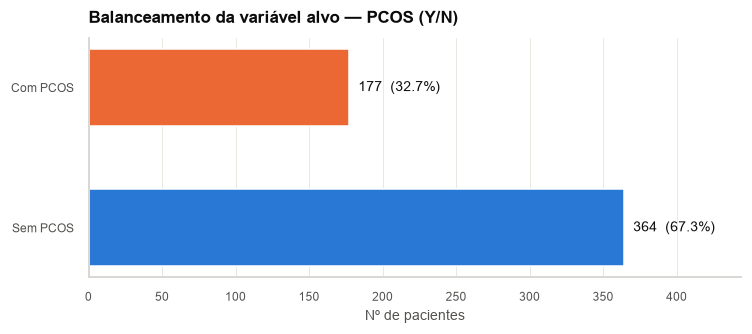

Razão entre as classes: 1 caso de PCOS para cada 2.06 sem PCOS.


In [29]:
contagem = eda[ALVO].value_counts().sort_index()
total = int(contagem.sum())

fig, ax = plt.subplots(figsize=(7, 3.2))
barras = ax.barh([ROTULOS_ALVO.get(i, str(i)) for i in contagem.index],
                 contagem.values, color=PALETA_ALVO[: len(contagem)], height=0.55)
for barra, valor in zip(barras, contagem.values):
    ax.text(barra.get_width() + total * 0.012,
            barra.get_y() + barra.get_height() / 2,
            f"{valor}  ({valor / total * 100:.1f}%)",
            va="center", fontsize=9, color=COR_TEXTO)
ax.set_xlim(0, contagem.max() * 1.22)
_estilizar(ax, f"Balanceamento da variável alvo — {ALVO}", xlabel="Nº de pacientes")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"Razão entre as classes: 1 caso de PCOS para cada "
      f"{contagem.get(0, 0) / max(contagem.get(1, 1), 1):.2f} sem PCOS.")

### Valores ausentes por coluna

Só aparecem as colunas com pelo menos um ausente (real ou disfarçado em texto).

> A barra de `Unnamed: 44` passa de 100%: o mesmo `NaN` é contado como nulo real **e** como
> token disfarçado. É um erro de contagem no relatório, não nos dados — ver **Gaps
> conhecidos** (item 2).

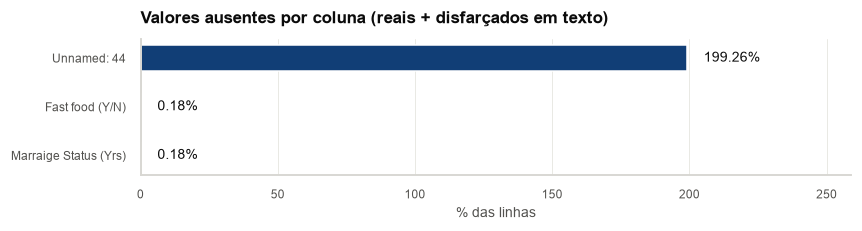

In [30]:
ausentes = df_unificado.isna().sum()
disfarcados = pd.Series(0, index=df_unificado.columns, dtype=int)
for coluna in df_unificado.select_dtypes(include="object").columns:
    disfarcados[coluna] = int(_mascara_ausentes_disfarcados(df_unificado[coluna]).sum())
ausentes = ausentes.add(disfarcados, fill_value=0)
ausentes = (ausentes[ausentes > 0] / len(df_unificado) * 100).sort_values()

if ausentes.empty:
    print("Nenhuma coluna com valores ausentes.")
else:
    fig, ax = plt.subplots(figsize=(8, max(2.2, 0.42 * len(ausentes) + 1)))
    cores = [CMAP_SEQUENCIAL(0.35 + 0.6 * v) for v in ausentes / max(ausentes.max(), 1e-9)]
    barras = ax.barh(ausentes.index, ausentes.values, color=cores, height=0.55)
    for barra, valor in zip(barras, ausentes.values):
        ax.text(barra.get_width() + ausentes.max() * 0.03,
                barra.get_y() + barra.get_height() / 2,
                f"{valor:.2f}%", va="center", fontsize=9, color=COR_TEXTO)
    ax.set_xlim(0, ausentes.max() * 1.3)
    _estilizar(ax, "Valores ausentes por coluna (reais + disfarçados em texto)",
               xlabel="% das linhas")
    ax.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.show()

### Correlação entre as variáveis

Escala divergente centrada em zero: azul = correlação negativa, cinza = sem relação
linear, vermelho = positiva. O recorte é das 15 variáveis mais correlacionadas com o alvo
— a matriz completa (41×41) fica ilegível impressa.

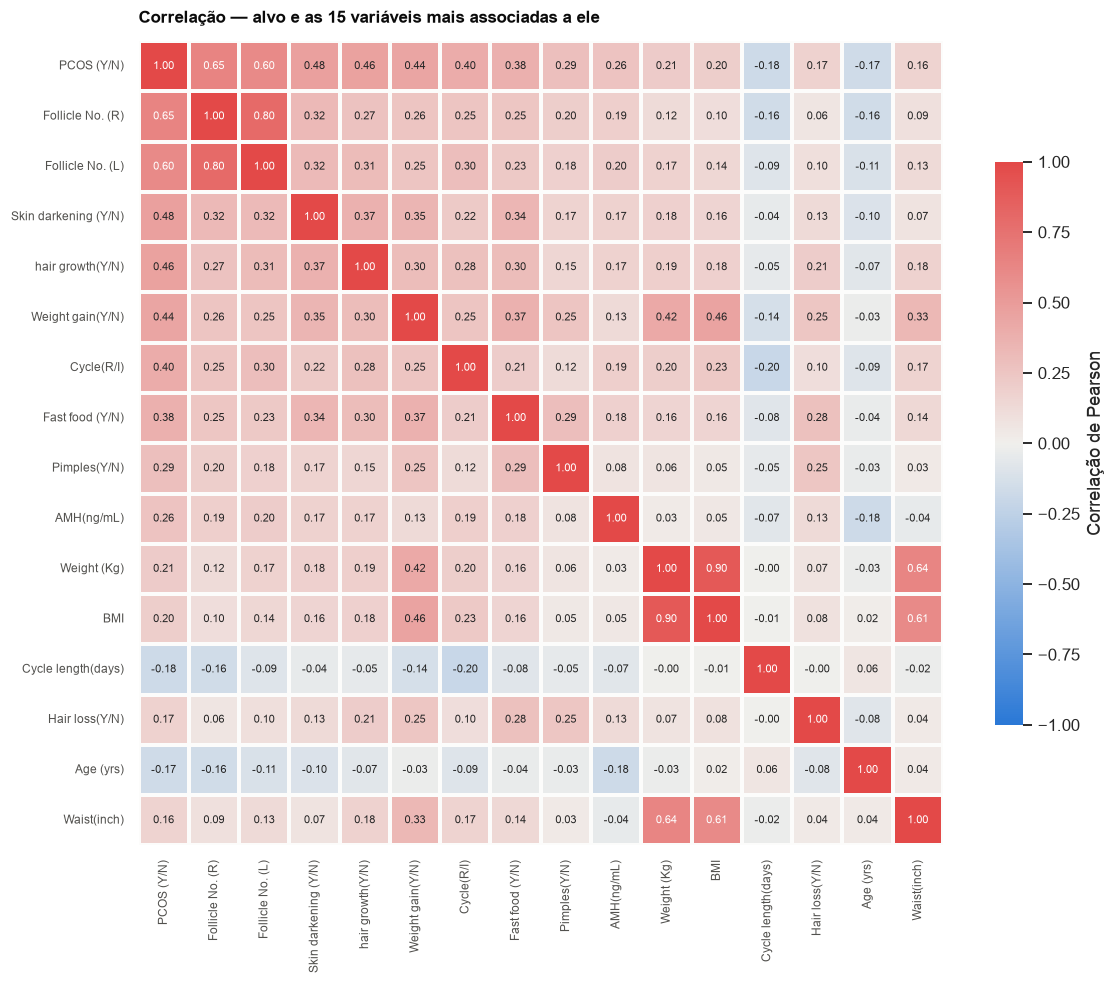

In [31]:
correlacao_alvo = eda[COLUNAS_EDA].corr()[ALVO].drop(ALVO)
top_15 = correlacao_alvo.abs().sort_values(ascending=False).head(15).index.tolist()
matriz = eda[[ALVO] + top_15].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(matriz, cmap=CMAP_DIVERGENTE, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=1.5, linecolor="#fcfcfb", square=True,
            cbar_kws={"label": "Correlação de Pearson", "shrink": 0.7}, ax=ax)
ax.set_title("Correlação — alvo e as 15 variáveis mais associadas a ele",
             loc="left", fontsize=11, fontweight="bold", color=COR_TEXTO, pad=12)
ax.tick_params(labelsize=8, colors=COR_TEXTO_SEC)
plt.tight_layout()
plt.show()

### Correlação de cada variável com o alvo

O mesmo dado do heatmap, mas ordenado — é a leitura mais direta de "o que acompanha o
diagnóstico".

> Isto é um **relatório**, não uma seleção de features: nenhuma coluna é removida com base
> nesta ordenação. Descartar variável por correlação é decisão de modelagem, fora do
> escopo deste notebook.

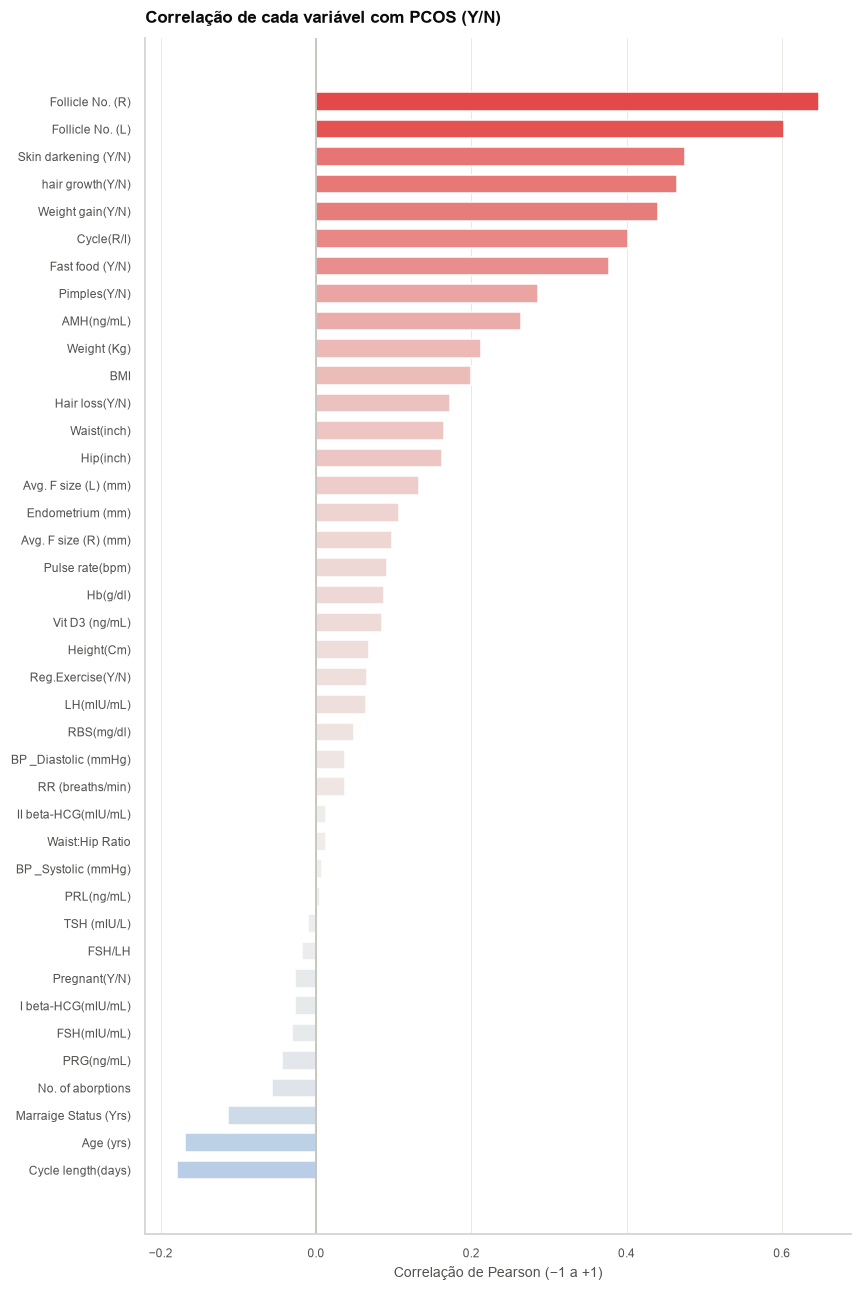

5 maiores correlações POSITIVAS com o alvo:
Follicle No. (R)        0.648
Follicle No. (L)        0.603
Skin darkening (Y/N)    0.476
hair growth(Y/N)        0.465
Weight gain(Y/N)        0.441

5 maiores correlações NEGATIVAS com o alvo:
Cycle length(days)      -0.178
Age (yrs)               -0.169
Marraige Status (Yrs)   -0.113
No. of aborptions       -0.057
PRG(ng/mL)              -0.044


In [32]:
ordenado = correlacao_alvo.sort_values()

fig, ax = plt.subplots(figsize=(8, max(4, 0.26 * len(ordenado) + 1.5)))
# A intensidade é normalizada pela maior correlação observada, e não pelo
# intervalo teórico [-1, 1]: como nenhuma variável passa de 0.65, mapear em
# [-1, 1] deixaria todas as barras quase brancas. O neutro segue no zero,
# então o SINAL continua legível.
maior_absoluto = max(ordenado.abs().max(), 1e-9)
cores = [CMAP_DIVERGENTE(0.5 + 0.5 * v / maior_absoluto) for v in ordenado.values]
ax.barh(ordenado.index, ordenado.values, color=cores, height=0.68)
ax.axvline(0, color="#b9b8b2", linewidth=1)
_estilizar(ax, f"Correlação de cada variável com {ALVO}",
           xlabel="Correlação de Pearson (−1 a +1)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print("5 maiores correlações POSITIVAS com o alvo:")
print(ordenado.tail(5)[::-1].round(3).to_string())
print("\n5 maiores correlações NEGATIVAS com o alvo:")
print(ordenado.head(5).round(3).to_string())

> ### Hipótese 1 — circularidade diagnóstica (a mais importante)
>
> As duas variáveis no topo são a contagem de folículos, com folga sobre o resto. Isso não
> é descoberta: a contagem folicular é um dos três critérios de Rotterdam, usado para
> **atribuir** o diagnóstico. A variável mais preditiva do rótulo é uma das que criam o
> rótulo — um modelo treinado com ela não prevê PCOS, relê o laudo.
>
> Daí treinar dois modelos na etapa seguinte: um com tudo, outro **sem** as contagens
> foliculares. O segundo responde à pergunta útil ("dá para suspeitar antes do
> ultrassom?"); o primeiro serve de teto de referência.

### Forma das distribuições

Um histograma por variável contínua, com a mediana marcada. O número de assimetria (skew)
no título é o que justifica imputar por mediana na ETAPA 2.

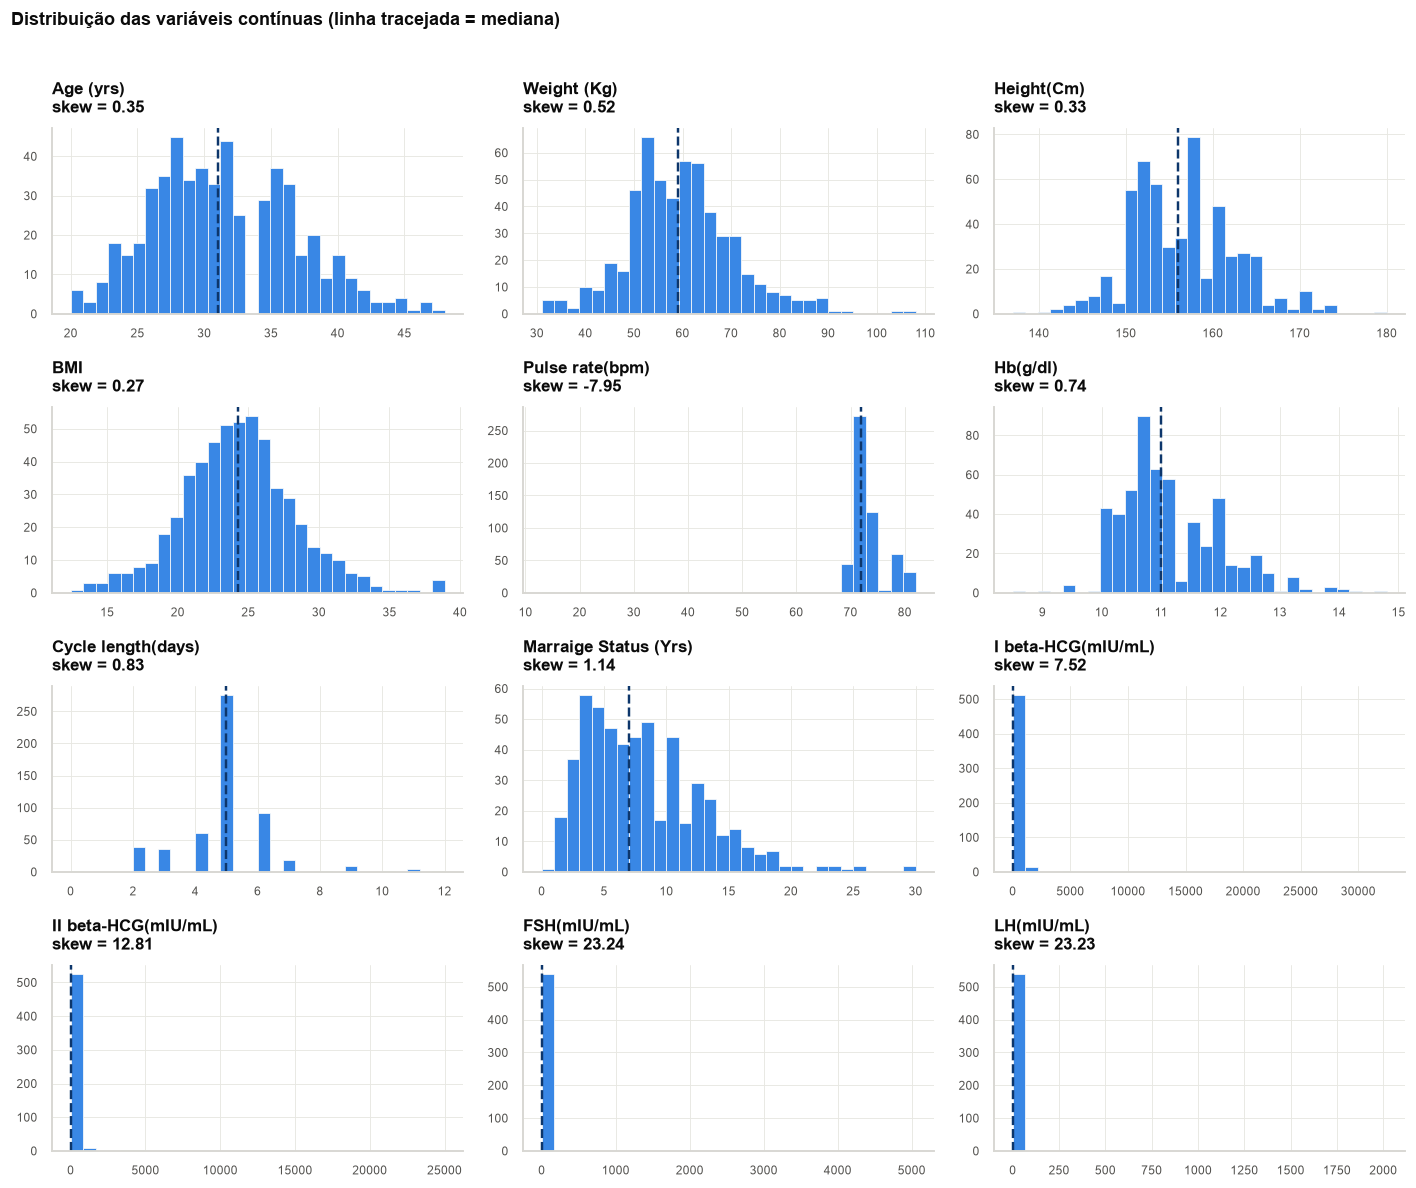

In [33]:
continuas = [c for c in COLUNAS_EDA if eda[c].nunique() > 10][:12]

fig, eixos = plt.subplots(4, 3, figsize=(13, 11))
for eixo, coluna in zip(eixos.flat, continuas):
    serie = eda[coluna].dropna()
    eixo.hist(serie, bins=30, color="#3987e5", edgecolor="#fcfcfb", linewidth=0.5)
    eixo.axvline(serie.median(), color="#0d366b", linewidth=1.6, linestyle="--")
    _estilizar(eixo, f"{coluna}\nskew = {serie.skew():.2f}")
    eixo.title.set_fontsize(9)
for eixo in eixos.flat[len(continuas):]:
    eixo.set_visible(False)
fig.suptitle("Distribuição das variáveis contínuas (linha tracejada = mediana)",
             x=0.01, ha="left", fontsize=12, fontweight="bold", color=COR_TEXTO)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

### As variáveis contínuas mais associadas ao alvo, por diagnóstico

**Só variáveis contínuas entram aqui.** O topo do ranking de correlação é dominado por
colunas binárias `(Y/N)`, e o boxplot de uma variável que só vale 0 ou 1 é um retângulo
cheio — não comunica nada. Essas colunas ganham o gráfico próprio da célula seguinte.

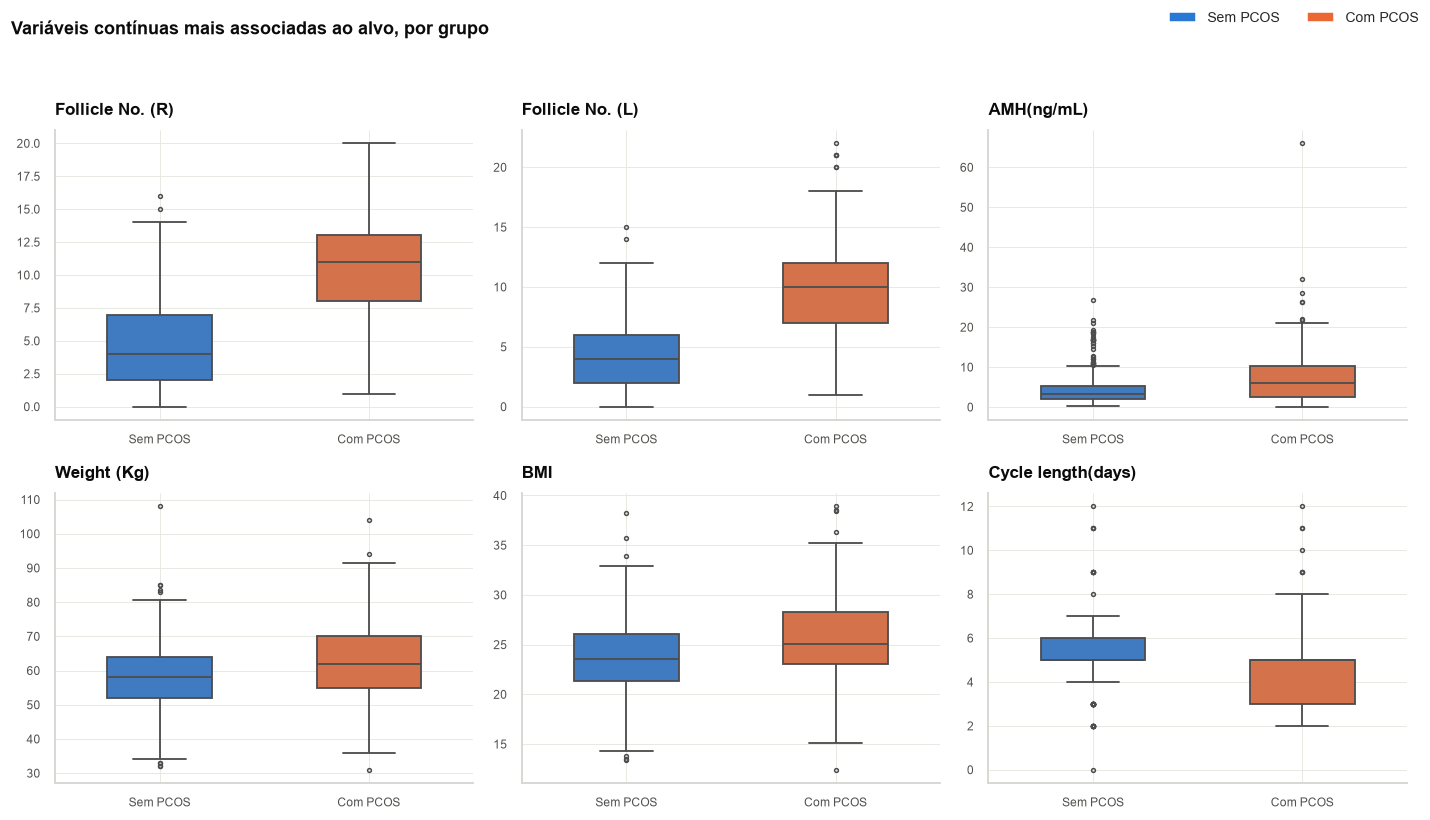

Age (yrs) — mediana sem PCOS: 32.0 | com PCOS: 29.0
Cycle length(days) — mediana sem PCOS: 5.0 | com PCOS: 5.0
Cycle length(days) — min 0, max 12, moda 5


In [34]:
destaques = [c for c in top_15 if eda[c].nunique() > 10][:6]
grupos = eda[ALVO].map(ROTULOS_ALVO)

fig, eixos = plt.subplots(2, 3, figsize=(13, 7.5))
for eixo, coluna in zip(eixos.flat, destaques):
    sns.boxplot(x=grupos, y=eda[coluna], hue=grupos, ax=eixo,
                palette={ROTULOS_ALVO[0]: COR_SEM_PCOS, ROTULOS_ALVO[1]: COR_COM_PCOS},
                legend=False, width=0.5, linewidth=1.2, fliersize=2.5,
                order=[ROTULOS_ALVO[0], ROTULOS_ALVO[1]])
    _estilizar(eixo, coluna)
    eixo.title.set_fontsize(9)
    eixo.set_xlabel("")

from matplotlib.patches import Patch

fig.legend(handles=[Patch(facecolor=COR_SEM_PCOS, label=ROTULOS_ALVO[0]),
                    Patch(facecolor=COR_COM_PCOS, label=ROTULOS_ALVO[1])],
           loc="upper right", frameon=False, fontsize=9, ncol=2)
fig.suptitle("Variáveis contínuas mais associadas ao alvo, por grupo",
             x=0.01, ha="left", fontsize=12, fontweight="bold", color=COR_TEXTO)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

for coluna in ["Age (yrs)", "Cycle length(days)"]:
    if coluna in eda.columns:
        medianas = eda.groupby(ALVO)[coluna].median()
        print(f"{coluna} — mediana sem PCOS: {medianas.get(0)} | com PCOS: {medianas.get(1)}")
if "Cycle length(days)" in eda.columns:
    serie = eda["Cycle length(days)"].dropna()
    print(f"Cycle length(days) — min {serie.min():.0f}, max {serie.max():.0f}, "
          f"moda {serie.mode().iloc[0]:.0f}")

> ### Hipótese 2 — a idade não protege; a amostra é que é enviesada
>
> A mediana de idade é **menor** no grupo com PCOS, e a leitura ingênua ("PCOS diminui com
> a idade") é quase certamente errada. Esta é uma amostra de clínica de fertilidade: o grupo
> *sem* PCOS não é a população geral, são mulheres que procuraram a clínica por **outras**
> causas de infertilidade — a principal delas a queda de fertilidade com a idade. O controle
> está cheio de pacientes mais velhas por construção.
>
> Para o modelo, idade segue sendo uma feature útil, mas o coeficiente mede o desenho do
> estudo, não a biologia: não interpretar causalmente nem extrapolar para fora da clínica.
>
> **Leitura à parte — `Cycle length(days)` está com o nome errado.** Os valores vão de 0 a
> 12, moda em 5, e um ciclo menstrual dura 21–35 dias: a coluna mede a **duração do fluxo**.
> A correlação negativa com PCOS diz "sangramento mais curto", não "ciclo mais curto".
>
> **Nota de qualidade.** `Cycle(R/I)` usa `2` (regular) e `4` (irregular), mas 1 paciente
> tem `5`, que não existe na convenção: sobrevive ao capping e chega ao CSV final — ver
> **Gaps conhecidos**.

### Sintomas binários: com que frequência aparecem em cada grupo

Para variável binária a pergunta não é "qual a distribuição?", e sim "que proporção de
cada grupo tem a característica?". Barras agrupadas respondem isso; o boxplot, não.

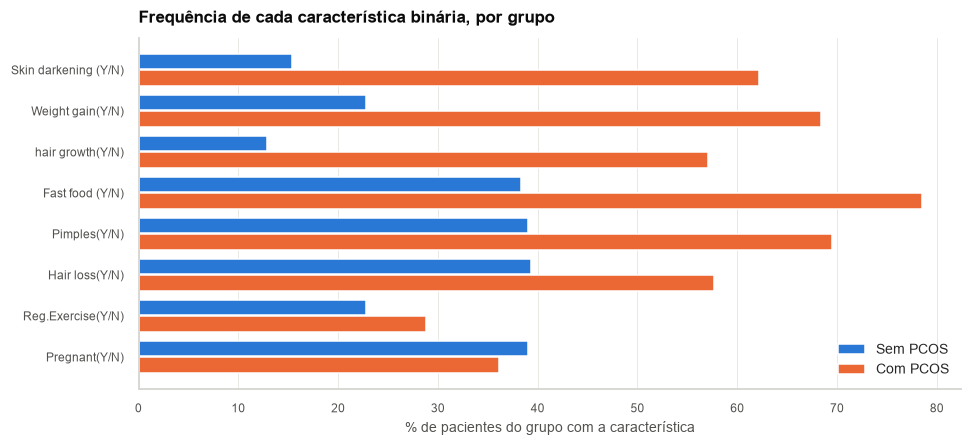

Maiores diferenças entre os grupos (pontos percentuais):
Skin darkening (Y/N)    46.8
Weight gain(Y/N)        45.6
hair growth(Y/N)        44.2
Fast food (Y/N)         40.2
Pimples(Y/N)            30.5

Correlação ENTRE os sintomas de hiperandrogenismo: 0.15 a 0.37


In [35]:
binarias = [c for c in COLUNAS_EDA
            if c != ALVO and set(eda[c].dropna().unique()) <= {0, 1}
            and eda[c].nunique() == 2]
# Ordena pela diferença entre os grupos: o que mais separa fica no topo.
proporcoes = eda.groupby(ALVO)[binarias].mean() * 100
diferenca = (proporcoes.loc[1] - proporcoes.loc[0]).sort_values()

posicoes = np.arange(len(diferenca))
fig, ax = plt.subplots(figsize=(9, max(4, 0.34 * len(diferenca) + 1.5)))
ax.barh(posicoes + 0.2, proporcoes.loc[0, diferenca.index], height=0.38,
        color=COR_SEM_PCOS, label=ROTULOS_ALVO[0])
ax.barh(posicoes - 0.2, proporcoes.loc[1, diferenca.index], height=0.38,
        color=COR_COM_PCOS, label=ROTULOS_ALVO[1])
ax.set_yticks(posicoes)
ax.set_yticklabels(diferenca.index)
_estilizar(ax, "Frequência de cada característica binária, por grupo",
           xlabel="% de pacientes do grupo com a característica")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

print("Maiores diferenças entre os grupos (pontos percentuais):")
print(diferenca.tail(5)[::-1].round(1).to_string())

# Os sintomas do topo co-ocorrem a ponto de virarem um índice único? (ver leitura abaixo)
sintomas = [c for c in binarias if any(
    k in c.lower() for k in ("skin darkening", "weight gain", "hair growth", "pimples"))]
entre_sintomas = eda[sintomas].corr().values[np.triu_indices(len(sintomas), k=1)]
print(f"\nCorrelação ENTRE os sintomas de hiperandrogenismo: "
      f"{entre_sintomas.min():.2f} a {entre_sintomas.max():.2f}")

> **Leitura.** Escurecimento de pele, ganho de peso, crescimento de pelos e acne formam o
> bloco de topo — manifestações de **hiperandrogenismo**, o segundo critério de Rotterdam
> (em grau menor que a Hipótese 1, por serem sintomas auto-relatados e não medida de exame).
>
> Não juntar tudo num índice: as correlações *entre* os sintomas ficam entre 0,15 e 0,37 —
> co-ocorrem de forma moderada, não formam um fator único, e somá-los perderia sinal.

### Contagem de folículos nos dois ovários

As duas variáveis do topo do ranking, cruzadas. As linhas tracejadas marcam **12
folículos**, o corte de Rotterdam.

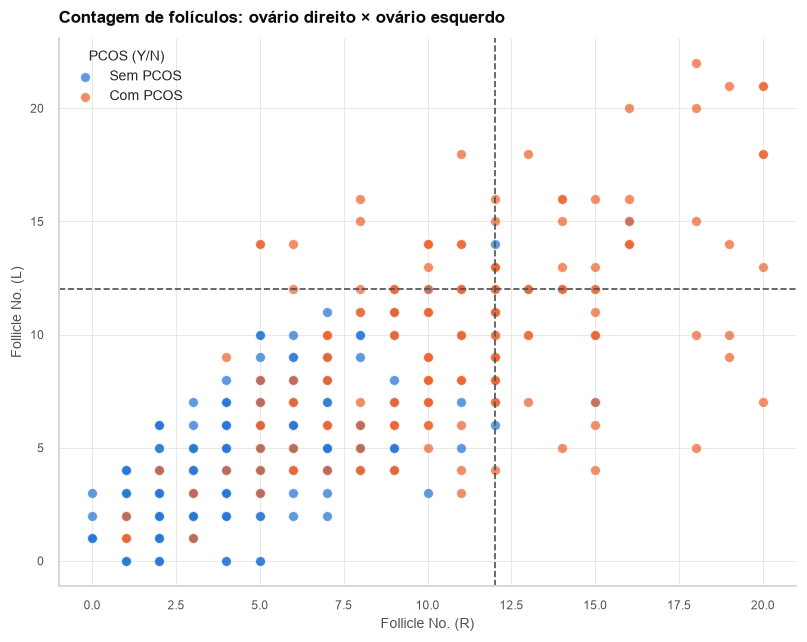

Correlação entre os dois ovários: r = 0.80
Sem PCOS: 2.5% cruzam o limiar de 12 folículos
Com PCOS: 53.7% cruzam o limiar de 12 folículos
Correlação AMH x contagem folicular (L): 0.20


In [36]:
col_esq = next((c for c in eda.columns if "follicle no. (l)" in str(c).lower()), None)
col_dir = next((c for c in eda.columns if "follicle no. (r)" in str(c).lower()), None)

if col_esq and col_dir:
    fig, ax = plt.subplots(figsize=(7.5, 6))
    for valor, cor in zip([0, 1], PALETA_ALVO):
        subconjunto = eda[eda[ALVO] == valor]
        ax.scatter(subconjunto[col_dir], subconjunto[col_esq], s=42, color=cor,
                   alpha=0.75, edgecolors="#fcfcfb", linewidths=0.6,
                   label=ROTULOS_ALVO[valor])
    # Corte de Rotterdam: 12 folículos em qualquer um dos ovários.
    ax.axvline(12, color=COR_TEXTO_SEC, linewidth=1.1, linestyle="--")
    ax.axhline(12, color=COR_TEXTO_SEC, linewidth=1.1, linestyle="--")
    _estilizar(ax, "Contagem de folículos: ovário direito × ovário esquerdo",
               xlabel=col_dir, ylabel=col_esq)
    ax.legend(frameon=False, fontsize=9, title=ALVO, title_fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"Correlação entre os dois ovários: r = {eda[col_esq].corr(eda[col_dir]):.2f}")
    cruza = (eda[col_esq] >= 12) | (eda[col_dir] >= 12)
    for valor in (0, 1):
        grupo = cruza[eda[ALVO] == valor]
        print(f"{ROTULOS_ALVO[valor]}: {grupo.mean() * 100:.1f}% cruzam o limiar de 12 folículos")

    amh = next((c for c in eda.columns if "amh" in str(c).lower()), None)
    if amh:
        print(f"Correlação AMH x contagem folicular (L): "
              f"{eda[amh].corr(eda[col_esq]):.2f}")
else:
    print("Colunas de contagem de folículos não encontradas.")

> ### Hipótese 3 — os dois ovários são a mesma medida
>
> `Follicle No. (L)` e `(R)` são fortemente correlacionados e a nuvem se organiza na
> diagonal: a policistose é bilateral, cada ovário é uma réplica ruidosa do outro. (A
> separação nítida na linha dos 12 folículos é a Hipótese 1 por outro ângulo.)
>
> Para o modelo isso é **multicolinearidade**: as duas dividem o mesmo coeficiente em
> modelos lineares e a mesma importância em árvores, diluindo as duas. Candidatas a virar
> uma feature só (soma, máximo ou média).
>
> **Contraponto — `AMH` não é redundante.** Apesar de o hormônio ser produzido pelos
> folículos antrais, sua correlação com a contagem é baixa: carrega sinal independente e
> sobrevive à remoção das contagens — a melhor candidata para o modelo "sem ultrassom".

---

### Síntese — o que levar para a modelagem

| # | Hipótese | Efeito na modelagem |
|---|---|---|
| 1 | Contagem folicular é critério diagnóstico, não preditor | treinar também **sem** folículos |
| 2 | Idade menor no grupo PCOS = viés de seleção | não interpretar idade causalmente |
| 3 | Ovários L/R são a mesma medida | fundir em uma feature |

**Ressalva que vale para todas.** Amostra de conveniência de uma clínica de fertilidade
(Kerala, Índia), 541 pacientes, sem grupo de controle populacional e sem eixo temporal.
Nada aqui sustenta conclusão causal — são direções de investigação, não achados.

<a id="etapa2"></a>
# ETAPA 2 — Tratamento

Daqui em diante os dados **são alterados**. Cada função corrige exatamente um problema
diagnosticado na ETAPA 1, recebe `(df, resumo)`, devolve o `df` e soma contadores no
dicionário `resumo`.

**A ordem importa:**

```
duplicidade → tipos → datas → espaços → colunas irrelevantes → colunas constantes
→ categorias → Yes/No → Blood Pressure → unidades → valores impossíveis
→ valores ausentes → outliers → Blood Group derivado
```

- **Colunas irrelevantes saem antes da imputação** — senão `Unnamed: 44` seria preenchida
  inteira com a mediana e o lixo de planilha viraria uma feature de aparência válida.
- **Tipos antes de qualquer cálculo:** mediana e IQR só existem sobre coluna numérica.
- **Valores impossíveis viram `NaN` antes da imputação** (para que a mediana os substitua)
  e antes do capping (para que não entrem no cálculo dos quartis).

In [68]:
def _resumo_vazio() -> dict:
    """Contadores do resumo final da ETAPA 2."""
    return {
        "linhas_removidas": 0,
        "duplicados_removidos": 0,
        "valores_ausentes_preenchidos": 0,
        "valores_impossiveis_corrigidos": 0,
        "valores_recuperados_na_juncao": 0,
        "outliers_tratados": 0,
        "datas_convertidas": 0,
        "tipos_corrigidos": [],
        "blood_pressure_separada": [],
        "yes_no_convertidos": [],
        "unidades_convertidas": [],
        "colunas_removidas": [],
        "blood_group_derivado": [],
    }

### [1] Linhas duplicadas

`keep="first"`: como as linhas seriam idênticas em **todas** as colunas, não há critério
de qualidade para preferir uma — a primeira é escolhida só para o resultado ser sempre o
mesmo.

In [69]:
def tratar_linhas_duplicadas(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: linhas totalmente duplicadas dão peso extra a um registro no treino.
    Estratégia: remover duplicatas exatas, mantendo a primeira ocorrência.
    Justificativa: o registro repetido não traz informação nova, só distorce as
    estatísticas da amostra.
    """
    linhas_antes = len(df)
    df = df.drop_duplicates(keep="first")
    removidas = linhas_antes - len(df)
    resumo["duplicados_removidos"] += removidas
    resumo["linhas_removidas"] += removidas
    return df

### [2] Tipos

Corrige o achado da verificação [4]: `AMH(ng/mL)` virou texto por causa de um único valor
`"a"`.

**Por que converter e não descartar a linha:** descartar perderia as outras 44 colunas
daquele paciente por causa de um valor sujo. O valor vira `NaN` e a imputação resolve
depois. O limiar de 90% impede que uma coluna de texto de verdade seja forçada a `NaN`.

In [39]:
def tratar_tipos(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: colunas quase todas numéricas ficam com tipo 'object' por
    sujeira pontual.
    Estratégia: pd.to_numeric(errors="coerce") nas colunas de texto em que
    >= 90% dos valores não nulos são convertíveis.
    Justificativa: preserva a linha inteira e deixa o valor sujo virar NaN,
    que a imputação resolve — sem perder as demais features do paciente.
    """
    for coluna in df.select_dtypes(include="object").columns:
        if coluna in COLUNAS_PROTEGIDAS:
            continue
        serie_texto = df[coluna].dropna().astype(str).str.strip()
        if serie_texto.empty:
            continue
        convertido = pd.to_numeric(serie_texto, errors="coerce")
        # O limiar é medido em uma cópia local ANTES de sobrescrever a coluna,
        # para não corromper texto genuíno.
        if convertido.notna().mean() >= 0.9:
            perdidos = int(convertido.isna().sum())
            df[coluna] = pd.to_numeric(df[coluna].astype(str).str.strip(), errors="coerce")
            resumo["tipos_corrigidos"].append(f"{coluna} (+{perdidos} NaN)")
    return df

### [3] Datas

Não há coluna de data neste dataset, então a função não altera nada. Ela usa o mesmo
padrão e o mesmo limiar do diagnóstico, para que "o que foi diagnosticado como data" seja
exatamente "o que é convertido".

In [40]:
def tratar_datas(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: datas podem estar guardadas como texto em formatos variados.
    Estratégia: converter com pd.to_datetime(errors="coerce") as colunas cujo
    padrão bate com _PADRAO_DATA na maioria dos valores.
    Justificativa: data como texto não permite cálculo de intervalo nem
    ordenação correta.
    """
    for coluna in df.select_dtypes(include="object").columns:
        if coluna in COLUNAS_PROTEGIDAS:
            continue
        serie_texto = df[coluna].dropna().astype(str).str.strip()
        if serie_texto.empty:
            continue
        if serie_texto.str.match(_PADRAO_DATA).mean() > 0.5:
            resumo["datas_convertidas"] += int(df[coluna].notna().sum())
            df[coluna] = pd.to_datetime(df[coluna], errors="coerce")
    return df

### [4] Espaços

Regex `\s+` → um espaço, mais `.strip()`. Resolve o caso real de
`'II    beta-HCG(mIU/mL)'`, com quatro espaços seguidos.

Os **nomes** de coluna já foram normalizados na junção; a função continua rodando porque
também trata os **valores** de texto (`" Yes"` e `"Yes"` seriam duas categorias diferentes
para um encoder).

In [41]:
def tratar_espacos(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: espaços nas bordas e espaços internos duplicados em nomes de
    coluna e em valores de texto quebram comparações e criam falsas categorias.
    Estratégia: colapsar espaços e remover os das bordas nos dois casos.
    Justificativa: sem isso, a mesma categoria aparece várias vezes e o sinal
    estatístico se dilui.
    """
    df = df.rename(columns=_normalizar_nome)
    for coluna in df.select_dtypes(include="object").columns:
        if coluna in COLUNAS_PROTEGIDAS:
            continue
        # isinstance(v, str): evita aplicar regex sobre NaN (float) na mesma coluna.
        df[coluna] = df[coluna].apply(
            lambda v: re.sub(r"\s+", " ", v).strip() if isinstance(v, str) else v
        )
    return df

### [5] Colunas irrelevantes

Remove colunas 100% vazias e colunas `Unnamed: N` com menos de 10% de preenchimento —
`Unnamed: 44` tem 2 valores em 541 linhas.

As colunas de ID **não** são removidas: ficam no arquivo de saída para manter a
rastreabilidade do registro. Elas já são excluídas das análises por
`_colunas_numericas_para_analise`.

In [42]:
def remover_colunas_irrelevantes(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: 'Unnamed: 44' é resíduo de formatação da planilha (2 de 541
    linhas preenchidas), sem valor analítico.
    Estratégia: remover colunas totalmente vazias e colunas 'Unnamed: N' com
    menos de 10% de preenchimento.
    Justificativa: manter essas colunas faria a imputação preenchê-las com a
    mediana, disfarçando lixo de planilha de dado válido.
    """
    colunas_vazias = [c for c in df.columns if df[c].isna().all()]
    colunas_unnamed = [
        c for c in df.columns
        if str(c).strip().lower().startswith("unnamed") and df[c].notna().mean() < 0.1
    ]
    remover = [c for c in sorted(set(colunas_vazias) | set(colunas_unnamed))
               if c not in COLUNAS_PROTEGIDAS]
    if remover:
        df = df.drop(columns=remover)
        resumo["colunas_removidas"].extend(remover)
    return df

### [6] Colunas constantes

Uma coluna com um só valor não separa nada. `dropna().nunique() == 1` conta os distintos
**ignorando** `NaN`: uma coluna com um único valor não nulo e o resto vazio também é
constante para este critério.

In [43]:
def remover_colunas_constantes(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: colunas com um único valor distinto não separam classe nenhuma.
    Estratégia: remover colunas com exatamente 1 valor distinto entre os não nulos.
    Justificativa: contribuição matematicamente nula para a classificação, e
    ainda podem causar divisão por zero em normalizações.
    """
    constantes = [c for c in df.columns
                  if df[c].dropna().nunique() == 1 and c not in COLUNAS_PROTEGIDAS]
    if constantes:
        df = df.drop(columns=constantes)
        resumo["colunas_removidas"].extend(constantes)
    return df

### [7] Padronização de categorias

Agrupa por chave normalizada (minúscula, sem espaços) e adota como forma final a **variante
mais frequente** do grupo, em vez de forçar tudo para minúsculas — assim a grafia mais
comum nos dados é preservada.

In [44]:
def padronizar_categorias(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: a mesma categoria com grafias diferentes ('Sim'/'SIM'/' sim')
    vira várias classes para um encoder.
    Estratégia: agrupar pela forma normalizada e substituir todas as variantes
    pela mais frequente do grupo.
    Justificativa: junta o que é a mesma coisa sem impor um estilo arbitrário.
    """
    for coluna in _colunas_texto(df):
        serie = df[coluna]
        nao_nulos = serie.dropna().astype(str)
        if nao_nulos.empty:
            continue
        mapa_canonico = (
            pd.DataFrame({"valor": nao_nulos, "chave": nao_nulos.str.strip().str.lower()})
            .groupby("chave")["valor"]
            .agg(lambda valores: valores.value_counts().idxmax())
        )
        df[coluna] = serie.apply(
            lambda v: mapa_canonico.get(str(v).strip().lower(), v) if isinstance(v, str) else v
        )
    return df

### [8] Yes/No → 0/1

Regra da aba `Instructions`. Aqui as colunas `(Y/N)` já chegam numéricas, então a função
detecta isso e não faz nada.

Valores não reconhecidos **não são forçados** para 0 ou 1: ficam como estão, para que um
valor inesperado continue visível.

In [45]:
def converter_yes_no(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: colunas Sim/Não podem vir como texto em várias formas
    (Yes/No, Y/N, Sim/Não, True/False).
    Estratégia: se já for numérica, não fazer nada; se for texto, mapear
    afirmativas para 1 e negativas para 0.
    Justificativa: modelo nenhum consome 'Yes'/'No' como texto, e forçar um
    valor desconhecido para 0/1 esconderia um erro de digitação.
    """
    mapa_sim = {"yes", "y", "sim", "s", "true", "1"}
    mapa_nao = {"no", "n", "não", "nao", "false", "0"}

    for coluna in df.columns:
        if "(y/n)" not in _normalizar_nome(coluna).lower():
            continue
        if pd.api.types.is_numeric_dtype(df[coluna]):
            continue  # já convertida — achado da verificação [11].

        def _mapear(valor):
            if pd.isna(valor):
                return valor
            chave = str(valor).strip().lower()
            if chave in mapa_sim:
                return 1
            if chave in mapa_nao:
                return 0
            return valor  # não reconhecido: mantido para análise manual.

        df[coluna] = df[coluna].apply(_mapear)
        resumo["yes_no_convertidos"].append(coluna)
    return df

### [9] Blood Pressure

Sistólica e diastólica são duas medidas diferentes; juntas em `"120/80"` não servem como
features numéricas. Aqui já vêm separadas, então a função não altera nada.

In [46]:
def separar_blood_pressure(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: a pressão arterial pode vir combinada no formato '120/80'.
    Estratégia: separar em duas colunas numéricas e remover a combinada; se já
    estiver separada, não fazer nada.
    Justificativa: são duas grandezas clínicas distintas e o texto '120/80' não
    pode ser usado em cálculo nenhum.
    """
    for coluna in list(df.select_dtypes(include="object").columns):
        if coluna in COLUNAS_PROTEGIDAS:
            continue
        valores = df[coluna].dropna().astype(str).str.strip()
        if valores.empty or valores.str.match(_PADRAO_PRESSAO_COMBINADA).mean() <= 0.5:
            continue
        # split(expand=True) devolve um mini-DataFrame, uma coluna por parte.
        partes = df[coluna].astype(str).str.strip().str.split("/", expand=True)
        df[f"{coluna}_Systolic"] = pd.to_numeric(partes[0], errors="coerce")
        df[f"{coluna}_Diastolic"] = pd.to_numeric(partes[1], errors="coerce")
        df = df.drop(columns=[coluna])
        resumo["blood_pressure_separada"].append(coluna)
    return df

### [10] Unidades

Converte altura de pés para centímetros (`× 30,48`) quando a coluna vier nessa unidade.
Aqui `Height(Cm)` já está em cm, então nada muda.

A detecção é pelo **nome** da coluna, não pela magnitude: um `5.8` tanto pode ser pés
quanto um erro de digitação em cm, enquanto o nome é um sinal explícito.

In [47]:
def converter_unidades(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: a altura pode estar em pés em vez de centímetros.
    Estratégia: converter as colunas cujo nome sinalize pés ('feet' ou '(ft)')
    multiplicando por 30.48.
    Justificativa: misturar unidades na mesma coluna inviabiliza qualquer
    comparação entre pacientes.
    """
    colunas_pes = [c for c in df.columns
                   if "feet" in _normalizar_nome(c).lower()
                   or "(ft)" in _normalizar_nome(c).lower()]
    for coluna in colunas_pes:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce") * 30.48
        resumo["unidades_convertidas"].append(coluna)
    return df

### [11] Valores impossíveis → `NaN`

**O que é feito:** os zeros achados na verificação [12] — `Avg. F size (L/R)` e
`Endometrium` — viram `NaN`, para serem imputados na etapa seguinte.

**Por que `NaN` e não tratar como outlier:** um `Endometrium = 0` não é uma medida extrema,
é a ausência de medida gravada como `0`. O capping por IQR o grudaria no limite inferior,
transformando um dado que não existe num número plausível e **falso** — o modelo passaria a
aprender sobre um valor inventado, sem nenhum sinal de que ele é inventado.

In [48]:
def tratar_valores_impossiveis(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: valores numéricos e presentes, mas que não podem existir
    (negativos em grandezas não-negativas; zeros em grandezas clínicas que não
    podem ser zero). Nenhuma checagem de tipo ou de ausência os captura.
    Estratégia: convertê-los para NaN, para que a imputação por mediana os
    substitua por um valor central plausível.
    Justificativa: preserva a linha inteira e impede que um "não medido"
    gravado como 0 puxe média, mediana e correlação da coluna.
    """
    for coluna in df.select_dtypes(include=[np.number]).columns:
        nome_normalizado = _normalizar_nome(coluna).lower()
        if coluna in COLUNAS_PROTEGIDAS or nome_normalizado in CANDIDATOS_ID:
            continue

        invalido = pd.Series(False, index=df.index)
        if any(p in nome_normalizado for p in _PALAVRAS_CHAVE_NAO_NEGATIVAS):
            invalido |= df[coluna] < 0
        if (any(p in nome_normalizado for p in _PALAVRAS_CHAVE_NAO_ZERO)
                and not _zero_e_legitimo(df, coluna)):
            invalido |= df[coluna] == 0
        invalido &= df[coluna].notna()

        quantidade = int(invalido.sum())
        if quantidade:
            df.loc[invalido, coluna] = np.nan
            resumo["valores_impossiveis_corrigidos"] += quantidade
            print(f"  '{coluna}': {quantidade} valor(es) impossível(is) -> NaN.")
    return df

### [12] Valores ausentes

**O que é feito:** duas fases — primeiro os tokens disfarçados (`"-"`, `"N/A"`, …) viram
`NaN` de verdade, sem o que a imputação nem os enxergaria; depois, a imputação.

- **Numéricas → mediana.** A média seria puxada pelos mesmos outliers que a verificação [5]
  encontrou (e que só são tratados **depois**), produzindo um valor de preenchimento
  distorcido e deslocando a distribuição que o modelo vê.
- **Texto → moda.** Mediana não existe para categoria.

`Blood Group` chega sem `NaN`, então nada muda ali — e a proteção daquela coluna é contra
*conversão de valor*, não contra imputação.

In [49]:
def tratar_valores_ausentes(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: valores ausentes (reais ou disfarçados em texto) impedem o uso
    da coluna pela maioria dos algoritmos.
    Estratégia: normalizar os tokens de ausência para NaN e imputar as
    numéricas com a mediana e as de texto com a moda.
    Justificativa: a mediana é imune aos outliers ainda não tratados, e a moda
    é a estatística central análoga para categoria.
    """
    for coluna in df.select_dtypes(include="object").columns:
        mascara = _mascara_ausentes_disfarcados(df[coluna].astype(str))
        # notna() evita reprocessar células já NaN (str(NaN) vira "nan", que
        # também está na lista de tokens).
        df.loc[df[coluna].notna() & mascara, coluna] = pd.NA

    for coluna in df.columns:
        qtd_ausente = int(df[coluna].isna().sum())
        if qtd_ausente == 0:
            continue
        if pd.api.types.is_numeric_dtype(df[coluna]):
            valor_imputado = df[coluna].median()
        else:
            moda = df[coluna].mode(dropna=True)
            valor_imputado = moda.iloc[0] if not moda.empty else None
        if valor_imputado is not None and pd.notna(valor_imputado):
            df[coluna] = df[coluna].fillna(valor_imputado)
            resumo["valores_ausentes_preenchidos"] += qtd_ausente
    return df

### [13] Outliers — capping (winsorização)

**O que é feito:** valores fora de `[Q1 − 1,5·IQR, Q3 + 1,5·IQR]` são "grudados" no limite
mais próximo com `Series.clip()`, em vez de removidos.

**Por que capping e não remoção:** remover a linha descartaria todas as outras features
daquele paciente por causa de um extremo em uma delas. O capping neutraliza o peso do
extremo — que domina qualquer modelo linear ou baseado em distância — e mantém o registro
utilizável.

**Mesma salvaguarda da verificação [5]:** se `iqr == 0`, a coluna é pulada; senão a classe
minoritária inteira seria grudada no valor majoritário e desapareceria.

In [50]:
def tratar_outliers(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: outliers extremos distorcem médias, desvios e o ajuste de
    modelos sensíveis a escala.
    Estratégia: capping (winsorização) pelos limites de IQR nas colunas
    numéricas de análise.
    Justificativa: IQR e não Z-score porque nenhuma coluna passa no teste de
    normalidade; capping e não remoção para não perder a linha inteira.
    """
    for coluna in _colunas_numericas_para_analise(df):
        serie = df[coluna].dropna()
        if serie.empty or serie.nunique() <= 1:
            continue
        q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue  # caso degenerado: o capping colapsaria a coluna.
        limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        fora = ((df[coluna] < limite_inf) | (df[coluna] > limite_sup)) & df[coluna].notna()
        quantidade = int(fora.sum())
        if quantidade:
            df[coluna] = df[coluna].clip(lower=limite_inf, upper=limite_sup)
            resumo["outliers_tratados"] += quantidade
    return df

### [14] `Blood Group` → ABO + Rh

**O que é feito:** o código inteiro (11 a 18) é desdobrado em **ABO** (4 dummies) e **Rh**
(1 binária), e a coluna original é preservada.

**Por quê:** para o modelo o código é uma armadilha silenciosa — passa em qualquer checagem
de tipo, mas o algoritmo lê nele uma **ordem** (`18 > 11`) e uma **distância**
(`17 − 11 = 6`) que não existem. One-hot direto nos 8 códigos também não serve: o código 18
(AB−) tem 2 linhas em 541, e um dummy com 2 positivos é ruído que o modelo decora. Separado
nas duas dimensões biológicas, o menor grupo passa a ter 44 linhas (ABO) e 50 (Rh).

**A coluna original é preservada** porque a regra do dataset exige que os valores fiquem
como vieram — a função só *acrescenta* colunas.

In [51]:
def derivar_blood_group(df: pd.DataFrame, resumo: dict) -> pd.DataFrame:
    """Problema: 'Blood Group' é um código categórico (11-18) gravado como
    inteiro; o modelo o leria como grandeza ordinal, e o código 18 (AB-) tem
    só 2 linhas — pequeno demais para virar um dummy próprio.
    Estratégia: separar o código nas duas dimensões que ele empacota (sistema
    ABO e fator Rh) e gerar 5 colunas binárias NOVAS.
    Justificativa: cada coluna passa a carregar informação biológica real, sem
    tocar na coluna original (regra do dataset).
    """
    coluna = next((c for c in df.columns
                   if _normalizar_nome(c).lower() == "blood group"), None)
    if coluna is None:
        return df

    codigos = pd.to_numeric(df[coluna], errors="coerce")
    # Guarda: sem o mapa completo, uma linha não mapeada viraria zero em todas
    # as dummies — indistinguível de uma categoria legítima.
    if codigos.isna().any() or not codigos.isin(list(MAPA_BLOOD_GROUP)).all():
        fora = sorted(set(codigos.dropna()) - set(MAPA_BLOOD_GROUP))
        print(f"[ALERTA] '{coluna}' tem valores fora de MAPA_BLOOD_GROUP "
              f"({fora or 'valores ausentes'}) — derivação ignorada.")
        return df

    sistema_abo = codigos.map(lambda codigo: MAPA_BLOOD_GROUP[codigo][0])
    fator_rh = codigos.map(lambda codigo: MAPA_BLOOD_GROUP[codigo][1])

    criadas = []
    for tipo in ("A", "B", "AB", "O"):  # ordem fixa: saída estável entre execuções.
        nome = f"Blood Group ABO_{tipo}"
        df[nome] = (sistema_abo == tipo).astype("int64")
        criadas.append(nome)
    df["Blood Group Rh+"] = (fator_rh == "+").astype("int64")
    criadas.append("Blood Group Rh+")

    resumo["blood_group_derivado"] = criadas
    return df

### Orquestração, resumo e exportação

In [52]:
def executar_tratamento(nome: str, df: pd.DataFrame,
                        resumo_juncao: dict | None = None) -> tuple[pd.DataFrame, dict]:
    """Aplica a ETAPA 2 completa, na ordem correta, e devolve o DataFrame
    tratado com o resumo de contadores.

    'resumo_juncao' traz o que já foi feito na consolidação (valores
    recuperados, colunas repetidas descartadas), para que o relatório final
    cubra todo o caminho do dado.
    """
    resumo = _resumo_vazio()
    if resumo_juncao:
        resumo["valores_recuperados_na_juncao"] = resumo_juncao.get(
            "valores_recuperados_na_juncao", 0)
        resumo["colunas_removidas"].extend(resumo_juncao.get("colunas_removidas", []))

    df = tratar_linhas_duplicadas(df, resumo)
    df = tratar_tipos(df, resumo)
    df = tratar_datas(df, resumo)
    df = tratar_espacos(df, resumo)
    # Irrelevantes/constantes ANTES da imputação: senão a imputação preencheria
    # 'Unnamed: 44' inteira e a disfarçaria de coluna válida.
    df = remover_colunas_irrelevantes(df, resumo)
    df = remover_colunas_constantes(df, resumo)
    df = padronizar_categorias(df, resumo)
    df = converter_yes_no(df, resumo)
    df = separar_blood_pressure(df, resumo)
    df = converter_unidades(df, resumo)
    # Impossíveis -> NaN antes de imputar (para virarem mediana) e antes do
    # capping (para não entrarem no cálculo dos quartis).
    df = tratar_valores_impossiveis(df, resumo)
    df = tratar_valores_ausentes(df, resumo)
    df = tratar_outliers(df, resumo)
    # Por último: as derivadas de Blood Group entram já sobre a coluna imputada
    # e não participam do capping (são binárias 0/1).
    df = derivar_blood_group(df, resumo)
    return df, resumo


def imprimir_resumo(nome: str, resumo: dict) -> None:
    """Imprime o resumo final do tratamento."""
    print(f"\n{'=' * 78}\nRESUMO DO TRATAMENTO — {nome}\n{'=' * 78}")
    print(f"Linhas removidas: {resumo['linhas_removidas']}")
    print(f"Duplicados removidos: {resumo['duplicados_removidos']}")
    print(f"Valores recuperados na junção: {resumo['valores_recuperados_na_juncao']}")
    print(f"Colunas com tipo corrigido: {resumo['tipos_corrigidos'] or 'nenhuma'}")
    print(f"Valores impossíveis corrigidos: {resumo['valores_impossiveis_corrigidos']}")
    print(f"Valores ausentes preenchidos: {resumo['valores_ausentes_preenchidos']}")
    print(f"Outliers tratados (capping por IQR): {resumo['outliers_tratados']}")
    print(f"Datas convertidas: {resumo['datas_convertidas']}")
    print(f"Blood Pressure separada: {resumo['blood_pressure_separada'] or 'não aplicável (já separada)'}")
    print(f"Yes/No convertidos: {resumo['yes_no_convertidos'] or 'não aplicável (já em 0/1)'}")
    print(f"Unidades convertidas: {resumo['unidades_convertidas'] or 'não aplicável (já em cm)'}")
    print(f"Colunas removidas: {resumo['colunas_removidas'] or 'nenhuma'}")
    print(f"Blood Group derivado em: {resumo['blood_group_derivado'] or 'não aplicável'}")


def salvar_dataset(nome: str, df: pd.DataFrame, pasta_saida: Path = None) -> Path:
    """Salva o DataFrame tratado, respeitando a extensão do nome."""
    pasta_saida = Path(pasta_saida or OUTPUT_DIR)
    pasta_saida.mkdir(parents=True, exist_ok=True)
    caminho = pasta_saida / nome
    sufixo = caminho.suffix.lower()
    if sufixo == ".csv":
        df.to_csv(caminho, index=False)
    elif sufixo in (".xlsx", ".xls"):
        df.to_excel(caminho, index=False)
    else:
        raise ValueError(f"Extensão não suportada para salvar: {sufixo}")
    print(f"Dataset tratado salvo em: {caminho}")
    return caminho

O tratamento roda sobre uma **cópia** do dataset consolidado, para que `df_unificado`
continue intacto e sirva de referência na comparação antes × depois da próxima seção.

In [53]:
print(f"{'#' * 78}\nTRATAMENTO — {NOME_UNIFICADO}\n{'#' * 78}")
df_tratado, resumo = executar_tratamento(NOME_UNIFICADO, df_unificado.copy(), resumo_juncao)
imprimir_resumo(NOME_UNIFICADO, resumo)
caminho_saida = salvar_dataset(NOME_UNIFICADO, df_tratado)
df_tratado.head()

##############################################################################
TRATAMENTO — PCOS_unificado.csv
##############################################################################
  'Avg. F size (L) (mm)': 7 valor(es) impossível(is) -> NaN.
  'Avg. F size (R) (mm)': 1 valor(es) impossível(is) -> NaN.
  'Endometrium (mm)': 2 valor(es) impossível(is) -> NaN.

RESUMO DO TRATAMENTO — PCOS_unificado.csv
Linhas removidas: 0
Duplicados removidos: 0
Valores recuperados na junção: 1
Colunas com tipo corrigido: ['II beta-HCG(mIU/mL) (+0 NaN)', 'AMH(ng/mL) (+1 NaN)']
Valores impossíveis corrigidos: 10
Valores ausentes preenchidos: 13
Outliers tratados (capping por IQR): 714
Datas convertidas: 0
Blood Pressure separada: não aplicável (já separada)
Yes/No convertidos: não aplicável (já em 0/1)
Unidades convertidas: não aplicável (já em cm)
Colunas removidas: ['Patient File No._y', 'PCOS (Y/N)_y', 'I beta-HCG(mIU/mL)_y', 'II beta-HCG(mIU/mL)_y', 'AMH(ng/mL)_y', 'Unnamed: 44']
Blood Group d

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Blood Group ABO_A,Blood Group ABO_B,Blood Group ABO_AB,Blood Group ABO_O,Blood Group Rh+
0,1,1,0,28.0,44.6,152.0,19.300000,15,77,22,10.48,2,5.0,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.680,2.07,45.16,17.10,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,0,0,0,1,1
1,2,2,0,36.0,65.0,161.5,24.921163,15,74,20,11.70,2,5.0,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.160,1.53,20.09,55.05,0.75,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,0,0,0,1,1
2,3,3,1,33.0,68.8,165.0,25.270891,11,72,18,11.80,2,5.0,10.0,1,0,494.08,241.09,5.54,0.88,6.295455,40,36,0.900000,2.540,6.63,10.52,49.70,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,1,0,0,0,1
3,4,4,0,37.0,65.0,148.0,29.674945,13,72,20,12.00,2,5.0,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,6.705,1.22,36.90,33.40,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,0,1,0,0,1
4,5,5,0,25.0,52.0,161.0,20.060954,11,72,18,10.00,2,5.0,1.0,1,0,740.04,241.09,3.98,0.90,4.422222,37,30,0.810811,3.570,2.26,30.09,43.80,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,1,0,0,0,1


<a id="pos"></a>
# ETAPA 2.B — Antes × depois

A conferência final: o tratamento fez o que prometeu, e não fez o que não deveria.

In [54]:
antes, depois = df_unificado, df_tratado

comparacao = pd.DataFrame({
    "antes": [antes.shape[0], antes.shape[1], int(antes.isna().sum().sum()),
              int((antes.dtypes == "object").sum()), int(antes.duplicated().sum())],
    "depois": [depois.shape[0], depois.shape[1], int(depois.isna().sum().sum()),
               int((depois.dtypes == "object").sum()), int(depois.duplicated().sum())],
}, index=["linhas", "colunas", "valores ausentes (NaN)",
          "colunas dtype object", "linhas duplicadas"])
comparacao["variação"] = comparacao["depois"] - comparacao["antes"]
print(comparacao.to_string())

print(f"\nColunas removidas: {sorted(set(antes.columns) - set(depois.columns))}")
print(f"Colunas restantes com dtype object: {list(depois.select_dtypes(include='object').columns)}")
print(f"Nenhuma linha perdida: {antes.shape[0] == depois.shape[0]}")

                        antes  depois  variação
linhas                    541     541         0
colunas                    45      49         4
valores ausentes (NaN)    541       0      -541
colunas dtype object        3       0        -3
linhas duplicadas           0       0         0

Colunas removidas: ['Unnamed: 44']
Colunas restantes com dtype object: []
Nenhuma linha perdida: True


### Efeito do capping nas colunas mais afetadas

Boxplots pareados. O capping deve **encolher os bigodes** sem mexer na caixa (Q1, mediana,
Q3): se a caixa se deslocar muito, o tratamento distorceu o miolo da distribuição em vez de
só neutralizar as pontas.

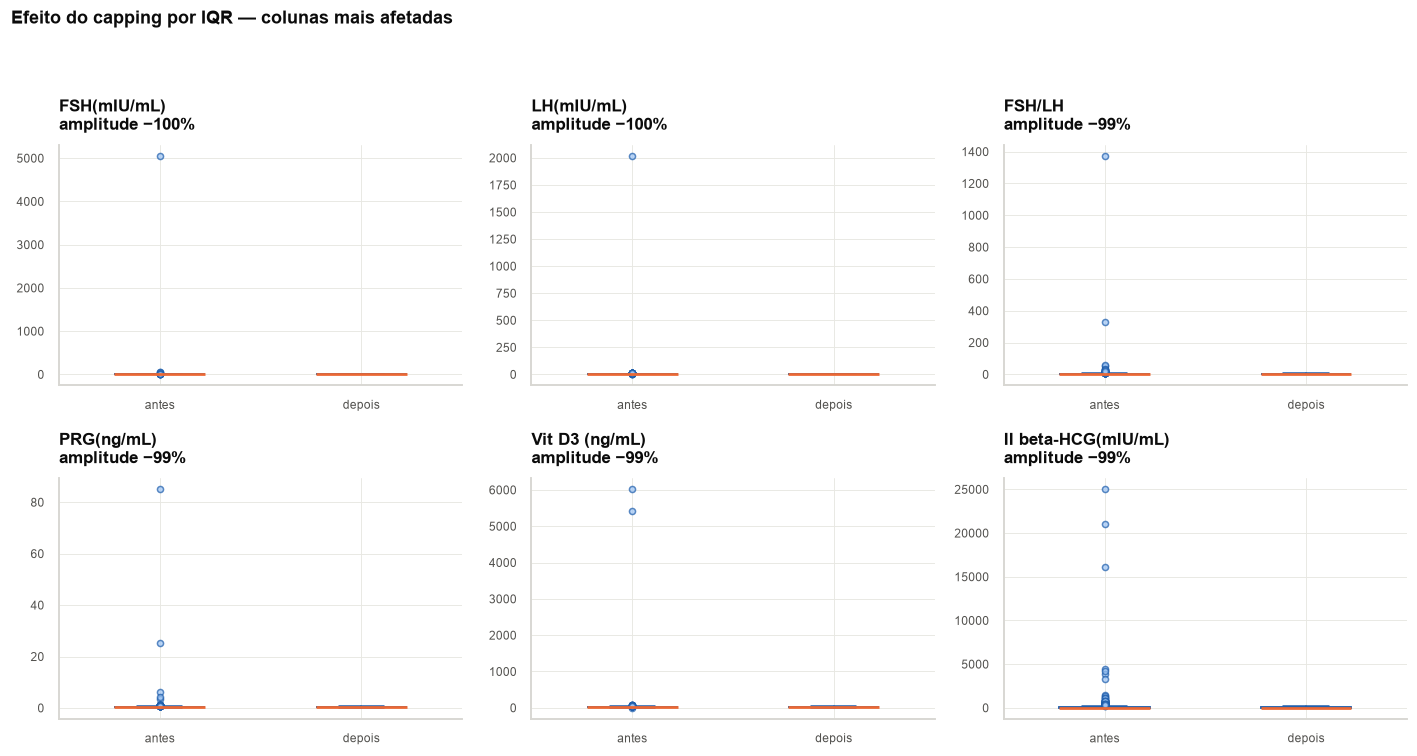

In [55]:
antes_num = _frame_numerico(antes)
numericas_comuns = [c for c in _colunas_numericas_para_analise(depois)
                    if c in antes_num.columns
                    and pd.api.types.is_numeric_dtype(antes_num[c])]

# Ordena pelas colunas em que o capping mais reduziu a amplitude.
reducao = {}
for coluna in numericas_comuns:
    amplitude_antes = antes_num[coluna].max() - antes_num[coluna].min()
    amplitude_depois = depois[coluna].max() - depois[coluna].min()
    if amplitude_antes and amplitude_antes > amplitude_depois:
        reducao[coluna] = 1 - amplitude_depois / amplitude_antes
mais_afetadas = sorted(reducao, key=reducao.get, reverse=True)[:6]

if not mais_afetadas:
    print("Nenhuma coluna teve a amplitude reduzida pelo capping.")
else:
    fig, eixos = plt.subplots(2, 3, figsize=(13, 7))
    for eixo, coluna in zip(eixos.flat, mais_afetadas):
        eixo.boxplot(
            [antes_num[coluna].dropna(), depois[coluna].dropna()],
            tick_labels=["antes", "depois"], widths=0.45, patch_artist=True,
            boxprops=dict(facecolor="#cde2fb", edgecolor="#1c5cab", linewidth=1.2),
            medianprops=dict(color="#eb6834", linewidth=1.8),
            whiskerprops=dict(color="#1c5cab"), capprops=dict(color="#1c5cab"),
            flierprops=dict(markerfacecolor="#9ec5f4", markeredgecolor="#1c5cab",
                            markersize=4, alpha=0.7),
        )
        _estilizar(eixo, f"{coluna}\namplitude −{reducao[coluna] * 100:.0f}%")
        eixo.title.set_fontsize(9)
    for eixo in eixos.flat[len(mais_afetadas):]:
        eixo.set_visible(False)
    fig.suptitle("Efeito do capping por IQR — colunas mais afetadas",
                 x=0.01, ha="left", fontsize=12, fontweight="bold", color=COR_TEXTO)
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

### Correlação com o alvo: antes × depois

O tratamento não pode inverter nem apagar as relações do dataset. Se alguma barra mudar de
sinal ou encolher demais, o tratamento alterou a estrutura dos dados e precisa ser revisto.

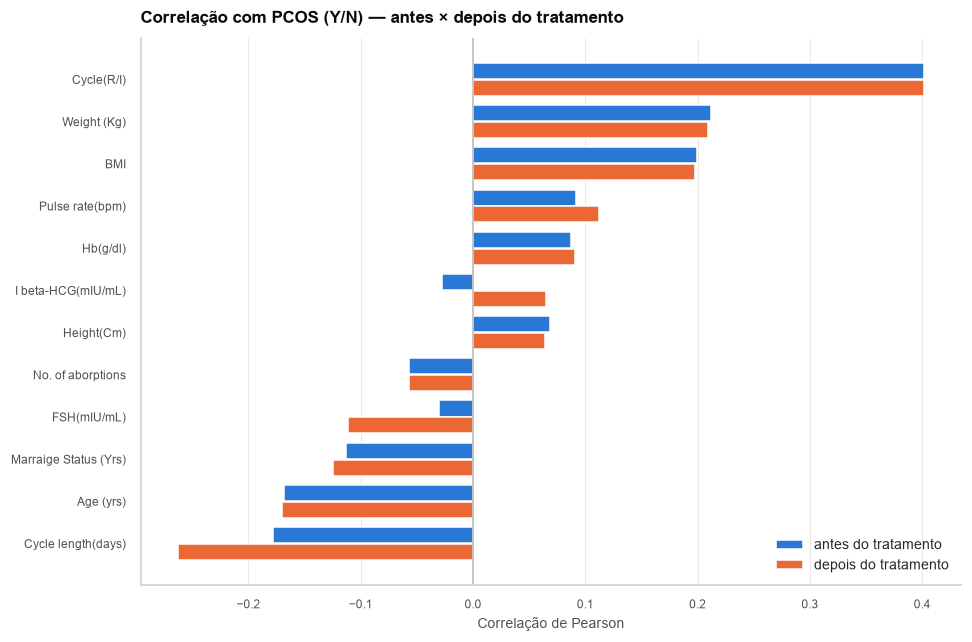

Maior variação absoluta de correlação: 0.093 (coluna 'I beta-HCG(mIU/mL)')

Colunas que trocaram o sinal da correlação: 1
  I beta-HCG(mIU/mL): -0.0276 -> +0.0651  (ruído: |r| < 0.1)

Nenhuma correlação relevante foi invertida: o tratamento preservou a estrutura dos dados.


In [56]:
alvo_final = _coluna_alvo(depois)
colunas_comparaveis = [c for c in numericas_comuns if c != alvo_final][:15]
colunas_comparaveis = (
    depois[colunas_comparaveis + [alvo_final]].corr()[alvo_final]
    .drop(alvo_final).abs().sort_values(ascending=False).head(12).index.tolist()
)

corr_antes = antes_num[colunas_comparaveis + [alvo_final]].corr()[alvo_final].drop(alvo_final)
corr_depois = depois[colunas_comparaveis + [alvo_final]].corr()[alvo_final].drop(alvo_final)
ordem = corr_depois.sort_values().index

posicoes = np.arange(len(ordem))
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(posicoes + 0.2, corr_antes[ordem].values, height=0.38,
        color=COR_SEM_PCOS, label="antes do tratamento")
ax.barh(posicoes - 0.2, corr_depois[ordem].values, height=0.38,
        color=COR_COM_PCOS, label="depois do tratamento")
ax.set_yticks(posicoes)
ax.set_yticklabels(ordem)
ax.axvline(0, color="#b9b8b2", linewidth=1)
_estilizar(ax, f"Correlação com {alvo_final} — antes × depois do tratamento",
           xlabel="Correlação de Pearson")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

variacao = (corr_depois - corr_antes).abs()
print(f"Maior variação absoluta de correlação: {variacao.max():.3f} "
      f"(coluna '{variacao.idxmax()}')")

# Uma troca de sinal só importa se a correlação tinha magnitude real: um +0.008
# que vira -0.006 é ruído em torno de zero. O limiar de 0.1 separa os dois casos.
trocaram = corr_antes[(corr_antes * corr_depois) < 0]
relevantes = [c for c in trocaram.index
              if max(abs(corr_antes[c]), abs(corr_depois[c])) >= 0.1]
print(f"\nColunas que trocaram o sinal da correlação: {len(trocaram)}")
for coluna in trocaram.index:
    marcador = "  <== RELEVANTE" if coluna in relevantes else "  (ruído: |r| < 0.1)"
    print(f"  {coluna}: {corr_antes[coluna]:+.4f} -> {corr_depois[coluna]:+.4f}{marcador}")

if relevantes:
    print(f"\n[ATENÇÃO] {len(relevantes)} correlação(ões) de magnitude real inverteram.")
else:
    print("\nNenhuma correlação relevante foi invertida: o tratamento preservou "
          "a estrutura dos dados.")

---

## Resultado

O dataset consolidado e tratado está em `base_dados_tratada/PCOS_unificado.csv`, pronto
para a modelagem: sem `NaN`, sem nenhuma coluna de texto, sem coluna constante ou vazia,
com outliers limitados por IQR, com `Blood Group` separado em ABO + Rh — e a coluna
`Blood Group` original preservada exatamente como veio, conforme a regra do dataset.
**Nenhuma linha foi perdida**: os 541 pacientes seguem íntegros.

O que este notebook deliberadamente **não** faz: divisão treino/teste, balanceamento
(SMOTE), normalização, seleção de features e treino de modelos. Tudo isso é etapa de
modelagem e pertence a um notebook seguinte — misturar as duas coisas aqui abriria porta
para vazamento de dados (*data leakage*), já que qualquer estatística calculada sobre o
dataset inteiro antes da divisão contamina o conjunto de teste.

---

## Gaps conhecidos

Levantamento das limitações deste pipeline, em ordem de impacto. Nenhuma delas foi
corrigida aqui — este notebook documenta o que encontrou.

**1. Valores absurdos porém não-zero escapam da verificação [12].** A regra de valores
impossíveis testa apenas `< 0` e `== 0`. O dataset tem `BP _Systolic = 12`,
`BP _Diastolic = 8`, e `Pulse rate` de `13` e `18` bpm — quase certamente `120/80` e
pulsos truncados na digitação. Como não são zeros, não viram `NaN`: chegam ao capping e são
grudados no limite inferior do IQR (≈95/55 mmHg, ≈69 bpm), virando números plausíveis e
falsos. É exatamente a falha que a verificação [11] argumenta evitar, só que por outra
porta. **Correção:** trocar o teste por faixas de plausibilidade clínica por grandeza.

**2. `verificar_valores_ausentes` conta `NaN` real duas vezes.** Em
`_mascara_ausentes_disfarcados`, `coluna.astype(str)` converte `NaN` na string `"nan"`, que
está em `TOKENS_AUSENTES` — então o mesmo valor entra na contagem de nulos reais e na de
disfarçados. É o que produz a linha `Unnamed: 44 … 199,26%` no diagnóstico e a barra de
199% no gráfico de ausentes. Afeta só o **relatório**: `tratar_valores_ausentes` já se
protege com `notna()`. **Correção:** somar `& coluna.notna()` na máscara. Nota: o efeito
depende da versão — visível no pandas 2.x, silencioso no pandas 3.x, onde `astype(str)`
preserva `NaN`.

**3. `Cycle(R/I) = 5` é diagnosticado mas nunca tratado.** A convenção é `2` (regular) e
`4` (irregular); 1 paciente tem `5`. O valor está dentro das cercas do IQR, sobrevive ao
capping e chega ao CSV final. Não existe verificação sistemática de domínio para colunas
codificadas que não terminam em `(Y/N)`.

**4. Mediana e cercas de IQR são calculadas sobre as 541 linhas.** A seção *Resultado*
diz que separar modelagem daqui evita leakage porque *"qualquer estatística calculada sobre
o dataset inteiro antes da divisão contamina o conjunto de teste"* — que é exatamente o que
a imputação por mediana e o capping por IQR fazem aqui. O dataset entregue já carrega
estatísticas globais embutidas; imputação e capping precisam ser **refeitos dentro de cada
fold** na etapa de modelagem, usando este CSV apenas como base limpa.

**5. O capping roda depois da imputação.** As medianas imputadas entram no cálculo dos
quartis e estreitam levemente as cercas. O efeito é pequeno aqui, mas a ordem correta é
calcular as cercas sobre os valores observados.

**6. `juntar_datasets` assume exatamente dois arquivos** (`list(dados)[0]` e `[1]`): um
terceiro arquivo de entrada seria ignorado em silêncio.